In [17]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import OLSInfluence
from sklearn.model_selection import GridSearchCV, cross_val_score, learning_curve, KFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats 

df_train = pd.read_csv('train_set_transformed.csv')
df_test = pd.read_csv('test_set_transformed.csv')
# Function to calculate MAPE (Mean Absolute Percentage Error)
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def run_model_with_top_features_and_qq_plot(df_train, df_test, model, param_grid, model_name="Model"):

    # Separate features and target variable in training and test datasets
    X_train = df_train[["Premium"]]
    y_train = df_train['Claim_costs']
    X_test = df_test[["Premium"]]
    y_test = df_test['Claim_costs']

    # Nested cross-validation with hyperparameter tuning
    def hyperparameter_tuning_with_nested_cv(model, param_grid, X_train, y_train):
        inner_cv = KFold(n_splits=5, shuffle=True, random_state=42)
        outer_cv = KFold(n_splits=5, shuffle=True, random_state=42)

        fold_metrics = []  # To store metrics for each fold

        for fold, (train_idx, valid_idx) in enumerate(outer_cv.split(X_train, y_train), start=1):
            X_fold_train, X_fold_valid = X_train.iloc[train_idx], X_train.iloc[valid_idx]
            y_fold_train, y_fold_valid = y_train.iloc[train_idx], y_train.iloc[valid_idx]

            # Run hyperparameter tuning on the training fold
            grid_search = RandomizedSearchCV(
                estimator=model,
                param_distributions=param_grid,
                cv=inner_cv,
                n_jobs=-1,
                scoring='neg_mean_squared_error',
                random_state=42
            )
            grid_search.fit(X_fold_train, y_fold_train)

            # Use the best model to predict the validation fold
            best_model = grid_search.best_estimator_
            y_pred_valid = best_model.predict(X_fold_valid)

            # Calculate metrics for the validation fold
            mse_fold = mean_squared_error(y_fold_valid, y_pred_valid)
            mae_fold = mean_absolute_error(y_fold_valid, y_pred_valid)

            # Print metrics for the fold
            print(f"Fold {fold} Results:")
            print(f"  Mean Squared Error (MSE): {mse_fold:.4f}")
            print(f"  Mean Absolute Error (MAE): {mae_fold:.4f}")

            # Store metrics for summary
            fold_metrics.append((fold, mse_fold, mae_fold))

        # After cross-validation, refit on the entire training set and return the best model
        grid_search.fit(X_train, y_train)
        best_model = grid_search.best_estimator_
        best_params = grid_search.best_params_

        return best_model, best_params, fold_metrics

    # Run nested CV and get the best model and fold metrics
    best_model, best_params, fold_metrics = hyperparameter_tuning_with_nested_cv(
        model, param_grid, X_train, y_train
    )

    print(f"\nBest Parameters from Grid Search for {model_name}:\n{best_params}\n")

    # Summary of metrics across folds
    print(f"\n{model_name} Cross-Validation Summary:")
    for fold, mse_fold, mae_fold in fold_metrics:
        print(f"  Fold {fold}: MSE = {mse_fold:.4f}, MAE = {mae_fold:.4f}")

    # Evaluate the model on the full test set
    y_pred_train = best_model.predict(X_train)
    y_pred_test = best_model.predict(X_test)
    residuals_train = y_train - y_pred_train
    residuals_test = y_test - y_pred_test

    # Calculate metrics for training and testing
    mse_train = mean_squared_error(y_train, y_pred_train)
    mae_train = mean_absolute_error(y_train, y_pred_train)
    r2_train = r2_score(y_train, y_pred_train)

    mse_test = mean_squared_error(y_test, y_pred_test)
    mae_test = mean_absolute_error(y_test, y_pred_test)
    r2_test = r2_score(y_test, y_pred_test)

    # Print evaluation results
    print(f"\n{model_name} Model Evaluation on Training Set:")
    print(f"Mean Squared Error (MSE - Training): {mse_train:.4f}")
    print(f"Mean Absolute Error (MAE - Training, Log Transformed): {mae_train:.4f}")
    print(f"R² Score (Training): {r2_train:.4f}")

    print(f"\n{model_name} Model Evaluation on Test Set:")
    print(f"Mean Squared Error (MSE - Testing): {mse_test:.4f}")
    print(f"Mean Absolute Error (MAE - Testing, Log Transformed): {mae_test:.4f}")
    print(f"R² Score (Testing): {r2_test:.4f}")

     # Convert log-transformed predictions and true values back to their original scale
    df_train['y_true'] = y_train.copy()  # Ensure it's a copy of y_test
    df_train['y_pred'] = y_pred_train
    df_train['y_pred_nolog'] = np.expm1(y_pred_train)  # Predicted values in original scale
    df_train['y_true_nolog'] = np.expm1(y_train) 
    mae_train_exp = mean_absolute_error(df_train['y_true_nolog'], df_train['y_pred_nolog'])
    mape_train_exp = mean_absolute_percentage_error(df_train['y_true_nolog'], df_train['y_pred_nolog'])
    print(f"Mean Absolute Percentage Error (MAPE - Training, Original Scale): {mape_train_exp:.4f}")
    print(f"Mean Absolute Error (MAE - Training, Original Scale): {mae_train_exp:.4f}")

    # Convert log-transformed predictions and true values back to their original scale
    df_test['y_true'] = y_test.copy()  # Ensure it's a copy of y_test
    df_test['y_pred'] = y_pred_test
    df_test['y_pred_nolog'] = np.expm1(y_pred_test)  # Predicted values in original scale
    df_test['y_true_nolog'] = np.expm1(y_test)     
    mae_test_exp = mean_absolute_error(df_test['y_true_nolog'], df_test['y_pred_nolog'])
    mape_test_exp = mean_absolute_percentage_error(df_test['y_true_nolog'], df_test['y_pred_nolog'])
    print(f"Mean Absolute Percentage Error (MAPE - Testing, Original Scale): {mape_test_exp:.4f}")
    print(f"Mean Absolute Error (MAE - Testing, Original Scale): {mae_test_exp:.4f}")

    # Store results in new DataFrames
    train_results = df_train.copy()
    test_results = df_test.copy()

    # Add predictions and residuals to DataFrames
    train_results['y_true'] = y_train
    train_results['y_pred'] = y_pred_train
    train_results['residuals'] = y_train - y_pred_train

    test_results['y_true'] = y_test
    test_results['y_pred'] = y_pred_test
    test_results['residuals'] = y_test - y_pred_test

    # Save results
    train_results.to_csv(f"{model_name.lower().replace(' ', '_')}_train.csv", index=False)
    test_results.to_csv(f"{model_name.lower().replace(' ', '_')}_test.csv", index=False)


    # Plot Actual vs Predicted
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, y_pred_test, alpha=0.6, edgecolor='k', label='Predictions')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
    plt.title(f"Actual vs. Predicted {model_name} Regressor", fontsize=14)
    plt.xlabel("Actual Cost Claims Year", fontsize=12)
    plt.ylabel("Predicted Cost Claims Year", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.show()

     # Plot Actual vs Predicted using original scale
    plt.figure(figsize=(10, 6))
    plt.scatter(np.exp(y_test), np.exp(y_pred_test), alpha=0.6, edgecolor='k', label='Predictions')
    plt.plot([np.exp(y_test).min(), np.exp(y_test).max()], 
             [np.exp(y_test).min(), np.exp(y_test).max()], 'r--', lw=2, label='Perfect Prediction')
    plt.title(f"Actual vs. Predicted {model_name} Regressor (Original Scale)", fontsize=14)
    plt.xlabel("Actual Cost Claims Year (Original Scale)", fontsize=12)
    plt.ylabel("Predicted Cost Claims Year (Original Scale)", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.show()

    # Plot Q-Q Plot for Residuals
    plt.figure(figsize=(8, 8))
    stats.probplot(residuals_test, dist="norm", plot=plt)
    plt.title(f"Q-Q Plot for {model_name} Residuals", fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()
    # Plot residuals and prediction density
    plot_residuals_and_qq(y_train, y_pred_train, y_test, y_pred_test, model_name)
    plot_residual_density(y_train, y_pred_train, y_test, y_pred_test, model_name)
    plot_prediction_kde(y_pred_train, y_pred_test, model_name)
    compute_cooks_and_leverage(X_test, y_test, y_pred_test, model_name, df_test)

    return best_model
# Density plot of residuals
def plot_residual_density(y_train_true, y_train_pred, y_test_true, y_test_pred, model_name):
    train_residuals, test_residuals = y_train_true - y_train_pred, y_test_true - y_test_pred
    plt.figure(figsize=(10, 6))
    sns.kdeplot(train_residuals, color='blue', fill=True, label='Train Residuals')
    sns.kdeplot(test_residuals, color='green', fill=True, label='Test Residuals')
    plt.title(f'Density Plot of Residuals for {model_name} (Claim Severity)')
    plt.xlabel('Residuals')
    plt.legend()
    plt.show()

# Density plot of predictions
def plot_prediction_kde(y_train_pred, y_test_pred, model_name):
    plt.figure(figsize=(10, 6))
    sns.kdeplot(y_train_pred, color='blue', fill=True, label='Train Predictions')
    sns.kdeplot(y_test_pred, color='green', fill=True, label='Test Predictions')
    plt.title(f'Kernel Density Plot of Predictions for {model_name} (Claim Severity)')
    plt.xlabel('Predicted Values')
    plt.legend()
    plt.show()

# Function to compute Cook's distance and leverage
def compute_cooks_and_leverage(X, y_true, y_pred, model_name, df):
    residuals = y_true - y_pred
    X_with_const = sm.add_constant(X)
    linear_model = sm.OLS(residuals, X_with_const).fit()
    influence = OLSInfluence(linear_model)
    leverage = influence.hat_matrix_diag
    cooks_d = influence.cooks_distance[0]
    leverage_threshold = 3 * np.mean(leverage)
    cooks_threshold = 4 / len(cooks_d)
    high_leverage_points = np.where(leverage > leverage_threshold)[0]
    high_cooks_points = np.where(cooks_d > cooks_threshold)[0]
    ids_high_leverage = df.loc[high_leverage_points, 'ID'].tolist()
    ids_high_cooks = df.loc[high_cooks_points, 'ID'].tolist()
    print(f"High leverage points IDs: {ids_high_leverage}")
    print(f"High Cook's distance points IDs: {ids_high_cooks}")
    return cooks_d, leverage, ids_high_leverage, ids_high_cooks

def plot_residuals_and_qq(y_train_true, y_train_pred, y_test_true, y_test_pred, model_name):
    train_residuals, test_residuals = y_train_true - y_train_pred, y_test_true - y_test_pred
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

    sns.scatterplot(x=y_train_pred, y=train_residuals, color='blue', ax=ax1, label=f'Train MAPE = {mean_absolute_percentage_error(y_train_true, y_train_pred):.3f}')
    sns.scatterplot(x=y_test_pred, y=test_residuals, color='green', ax=ax1, label=f'Test MAPE = {mean_absolute_percentage_error(y_test_true, y_test_pred):.3f}')
    ax1.axhline(0, color='black', linestyle='--')
    ax1.set_title(f'Residuals for {model_name} Model (Claim Severity)')
    stats.probplot(train_residuals, dist="norm", plot=ax2)
    stats.probplot(test_residuals, dist="norm", plot=ax2)
    plt.tight_layout()
    plt.show()



Linear Regression Evaluation:
Training Set:
  Mean Squared Error (MSE): 3679024.2089
  Mean Absolute Error (MAE): 554.2304
  R² Score: 0.0000
Test Set:
  Mean Squared Error (MSE): 1252152.3803
  Mean Absolute Error (MAE): 498.3933
  R² Score: -0.0032


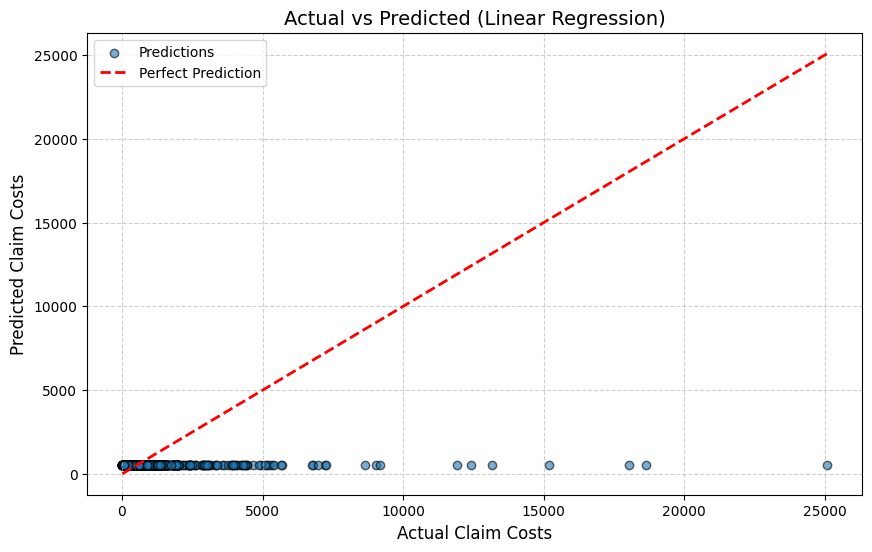

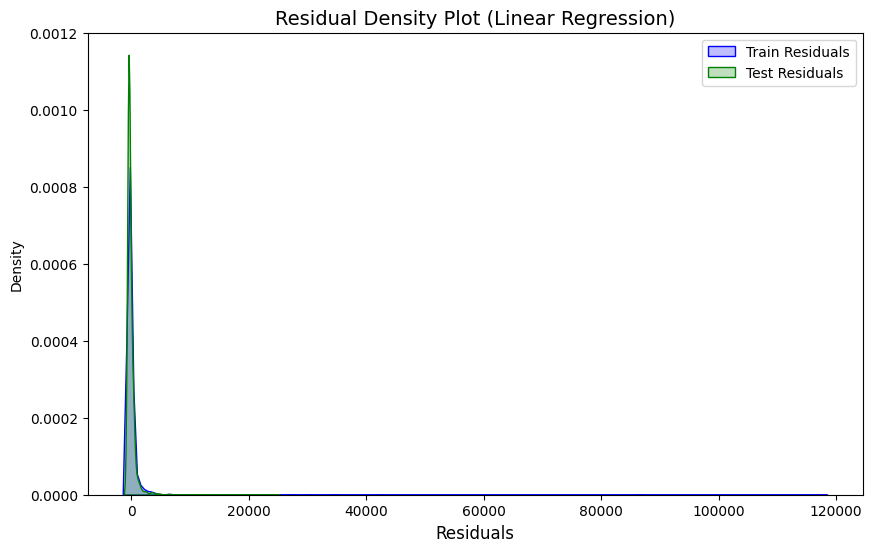

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import seaborn as sns

# Load the dataset
df_train = pd.read_csv('train_set_log.csv')
df_test = pd.read_csv('test_set_log.csv')

# Separate features and target variables
X_train = df_train[["N_claims_year"]]
y_train = df_train["Claim_costs"]
X_test = df_test[["N_claims_year"]]
y_test = df_test["Claim_costs"]

# Initialize Linear Regression Model
linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train, y_train)

# Make predictions
y_train_pred = linear_model.predict(X_train)
y_test_pred = linear_model.predict(X_test)

# Evaluate the model
mse_train = mean_squared_error(y_train, y_train_pred)
mae_train = mean_absolute_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)

mse_test = mean_squared_error(y_test, y_test_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

# Print the evaluation results
print("Linear Regression Evaluation:")
print(f"Training Set:")
print(f"  Mean Squared Error (MSE): {mse_train:.4f}")
print(f"  Mean Absolute Error (MAE): {mae_train:.4f}")
print(f"  R² Score: {r2_train:.4f}")

print(f"Test Set:")
print(f"  Mean Squared Error (MSE): {mse_test:.4f}")
print(f"  Mean Absolute Error (MAE): {mae_test:.4f}")
print(f"  R² Score: {r2_test:.4f}")

# Visualize Actual vs Predicted
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_test_pred, alpha=0.6, edgecolor='k', label="Predictions")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label="Perfect Prediction")
plt.title("Actual vs Predicted (Linear Regression)", fontsize=14)
plt.xlabel("Actual Claim Costs", fontsize=12)
plt.ylabel("Predicted Claim Costs", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()

# Visualize Residuals
residuals_train = y_train - y_train_pred
residuals_test = y_test - y_test_pred

plt.figure(figsize=(10, 6))
sns.kdeplot(residuals_train, color="blue", fill=True, label="Train Residuals")
sns.kdeplot(residuals_test, color="green", fill=True, label="Test Residuals")
plt.title("Residual Density Plot (Linear Regression)", fontsize=14)
plt.xlabel("Residuals", fontsize=12)
plt.legend()
plt.show()


Fold 1 Results:
  Mean Squared Error (MSE): 1.6123
  Mean Absolute Error (MAE): 1.0803
Fold 2 Results:
  Mean Squared Error (MSE): 1.5737
  Mean Absolute Error (MAE): 1.0553
Fold 3 Results:
  Mean Squared Error (MSE): 1.5654
  Mean Absolute Error (MAE): 1.0611
Fold 4 Results:
  Mean Squared Error (MSE): 1.5829
  Mean Absolute Error (MAE): 1.0598
Fold 5 Results:
  Mean Squared Error (MSE): 1.6278
  Mean Absolute Error (MAE): 1.0734

Best Parameters from Grid Search for XGBoost Regressor:
{'subsample': 0.8, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.8}


XGBoost Regressor Cross-Validation Summary:
  Fold 1: MSE = 1.6123, MAE = 1.0803
  Fold 2: MSE = 1.5737, MAE = 1.0553
  Fold 3: MSE = 1.5654, MAE = 1.0611
  Fold 4: MSE = 1.5829, MAE = 1.0598
  Fold 5: MSE = 1.6278, MAE = 1.0734

XGBoost Regressor Model Evaluation on Training Set:
Mean Squared Error (MSE - Training): 1.5821
Mean Absolute Error (MAE - Training, Log Transformed): 1.0624
R² Score (Trai

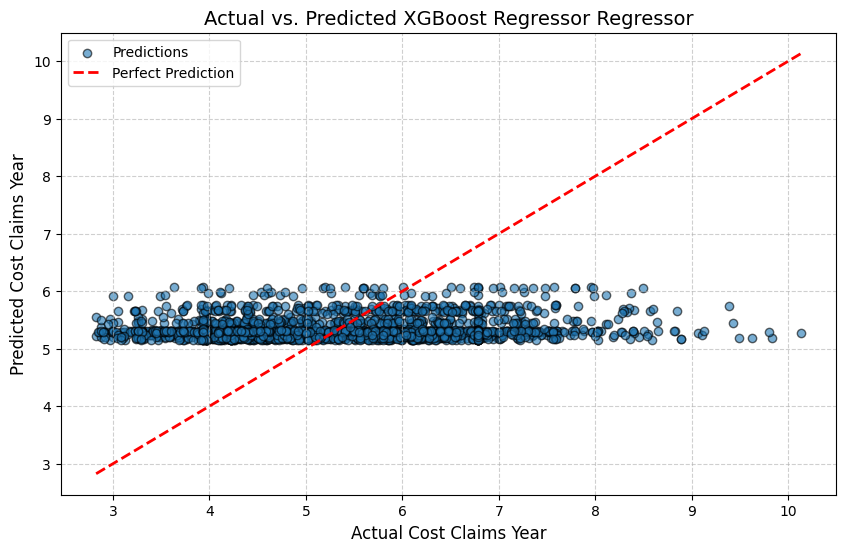

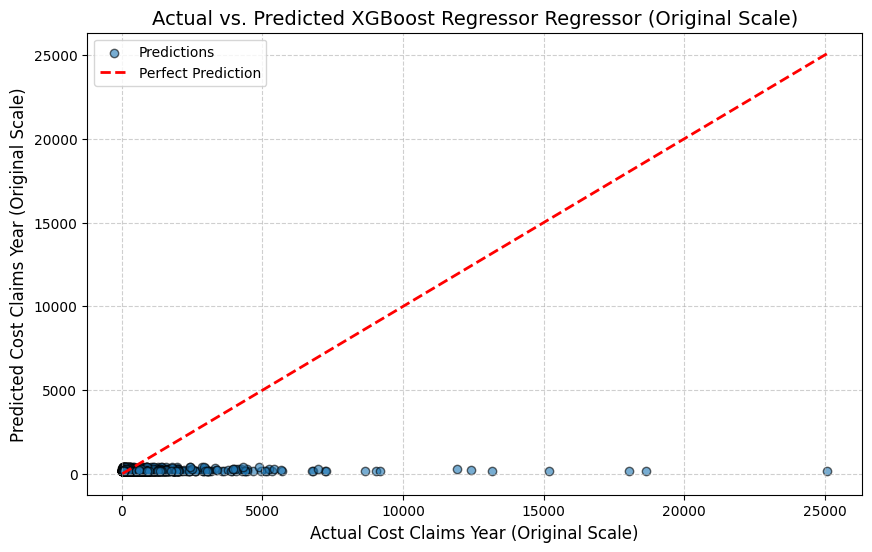

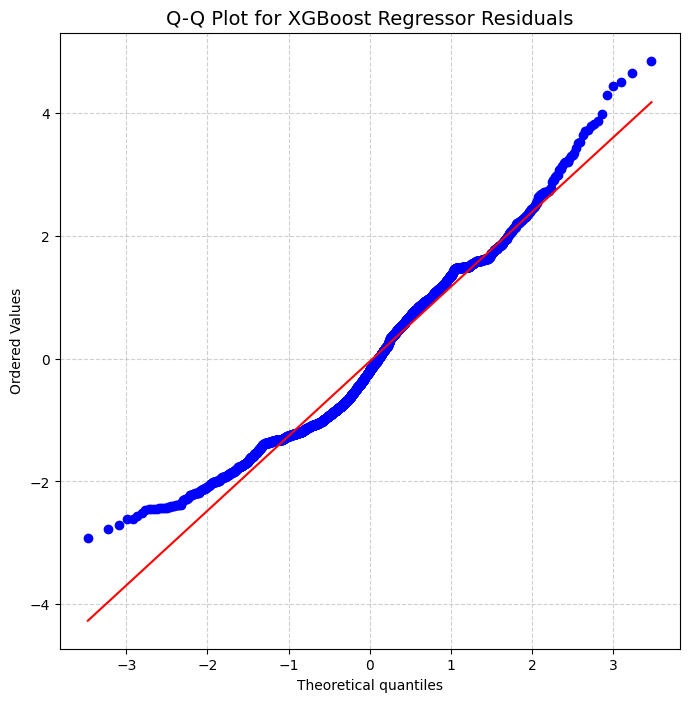

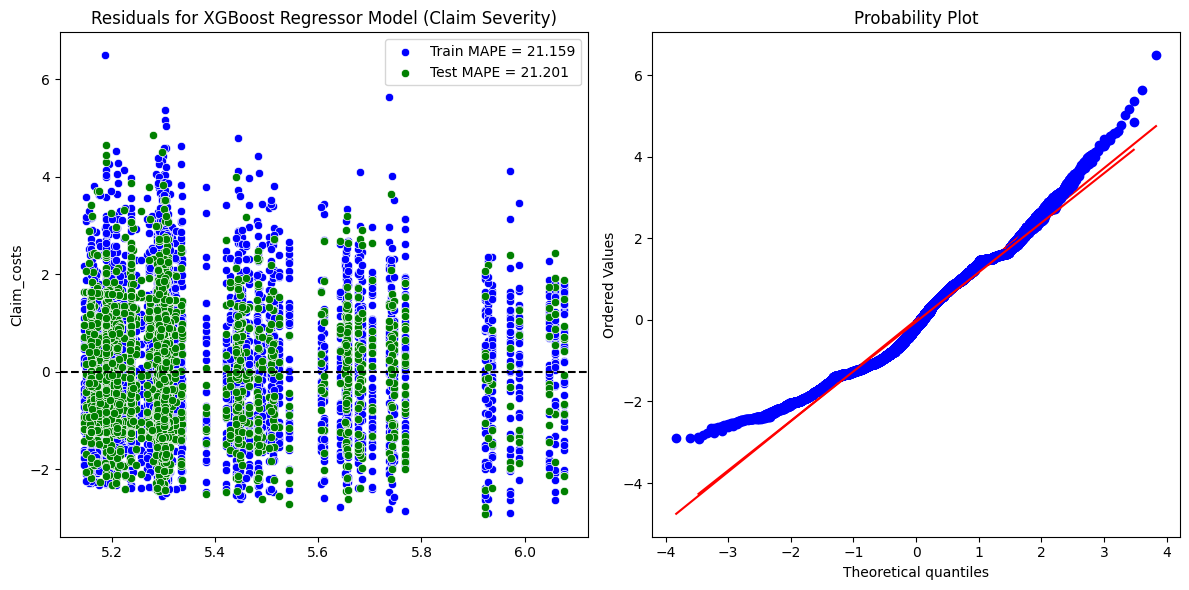

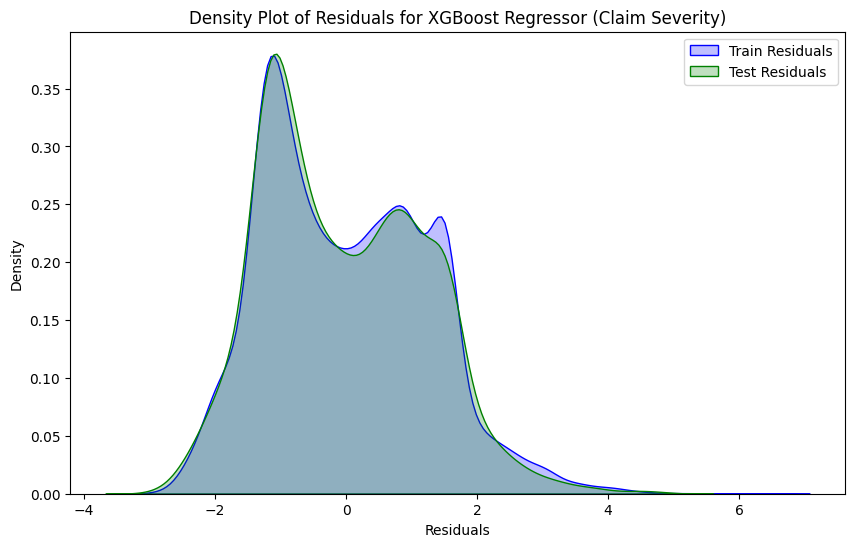

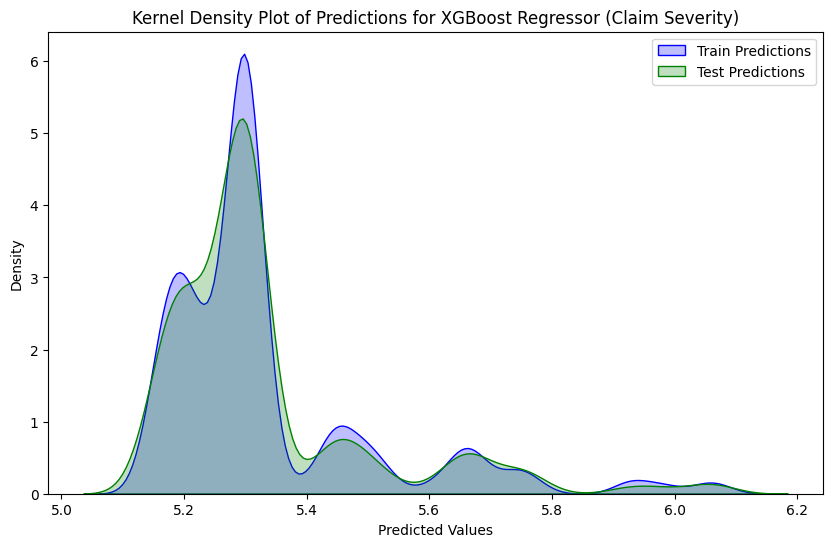

High leverage points IDs: [37493, 34044, 45073, 47327, 19522, 42932, 9039, 7867, 2294, 52528, 45422, 21215, 34881, 39127, 32463, 14983, 44824, 19967, 52897, 20530, 14370, 6097, 40554, 39406, 34594, 910, 44891, 21503, 22434, 35673, 14364, 32442, 8284, 52627, 53429, 52454, 34563, 48972, 23378, 7583, 45171, 39374, 26473, 52741, 44476, 33410, 30153, 26672, 3497, 12764, 14163, 9961, 41608, 27037, 38613, 52386, 48503, 53370, 50609, 19522, 35779, 21412, 44986, 21533, 30077, 12663, 5555, 31901, 39865, 3030, 44494, 39185, 34136, 37493, 32759, 34207, 38572, 28832, 4558, 38397, 9883, 30540, 16445, 48216, 52528, 40571, 33465, 7583, 51312, 7999, 11443, 5140]
High Cook's distance points IDs: [44043, 37039, 40925, 45073, 21388, 47327, 19522, 33268, 42932, 12130, 4088, 2294, 15038, 52528, 12397, 45422, 21215, 49116, 34881, 39127, 32463, 2501, 19453, 14983, 23842, 36018, 19967, 20530, 36661, 52524, 20596, 48667, 6165, 6345, 39149, 28531, 39406, 34594, 9622, 35673, 46263, 45359, 53429, 52454, 34563, 489

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.01, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=3, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=200, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

# Define the XGBoost regressor
model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# Define the parameter grid for hyperparameter tuning
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

run_model_with_top_features_and_qq_plot(
    df_train=df_train, 
    df_test=df_test, 
    model=model, 
    param_grid=param_grid, 
    model_name="XGBoost Regressor"
)



In [19]:
xg = pd.read_csv("xgboost_regressor_train.csv")
xg[['y_pred_nolog', 'y_true_nolog']].describe()


,y_pred_nolog,y_true_nolog
count,10828.000000,10828.000000
mean,210.939948,537.530294
std,46.658364,1918.199476
min,170.592350,14.530000
25%,184.776540,67.250000
50%,198.670970,181.215000
75%,201.976800,548.146250
max,434.108500,118142.590000


In [20]:
xg_test = pd.read_csv("xgboost_regressor_test.csv")
xg_test[['y_pred_nolog', 'y_true_nolog']].describe()


,y_pred_nolog,y_true_nolog
count,2707.000000,2707.000000
mean,209.941922,469.195328
std,45.329330,1117.439034
min,170.592350,15.863333
25%,186.728060,67.110000
50%,198.565610,168.820000
75%,201.583560,504.335000
max,434.108500,25071.950000


Fold 1 Results:
  Mean Squared Error (MSE): 0.0000
  Mean Absolute Error (MAE): 0.0005
Fold 2 Results:
  Mean Squared Error (MSE): 0.0000
  Mean Absolute Error (MAE): 0.0007
Fold 3 Results:
  Mean Squared Error (MSE): 0.0003
  Mean Absolute Error (MAE): 0.0012
Fold 4 Results:
  Mean Squared Error (MSE): 0.0000
  Mean Absolute Error (MAE): 0.0007
Fold 5 Results:
  Mean Squared Error (MSE): 0.0005
  Mean Absolute Error (MAE): 0.0011

Best Parameters from Grid Search for Random Forest:
{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': None}


Random Forest Cross-Validation Summary:
  Fold 1: MSE = 0.0000, MAE = 0.0005
  Fold 2: MSE = 0.0000, MAE = 0.0007
  Fold 3: MSE = 0.0003, MAE = 0.0012
  Fold 4: MSE = 0.0000, MAE = 0.0007
  Fold 5: MSE = 0.0005, MAE = 0.0011

Random Forest Model Evaluation on Training Set:
Mean Squared Error (MSE - Training): 0.0000
Mean Absolute Error (MAE - Training, Log Transformed): 0.0003
R² Score (Training): 1.0000

Random Forest

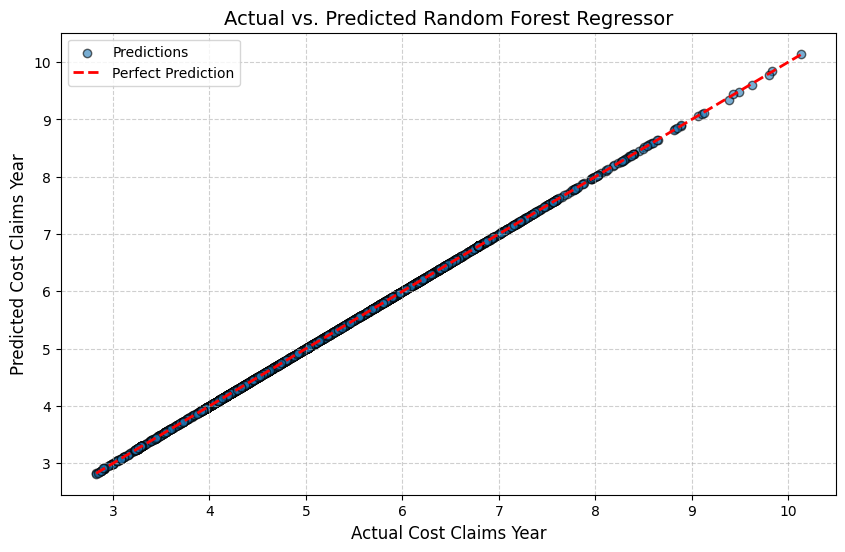

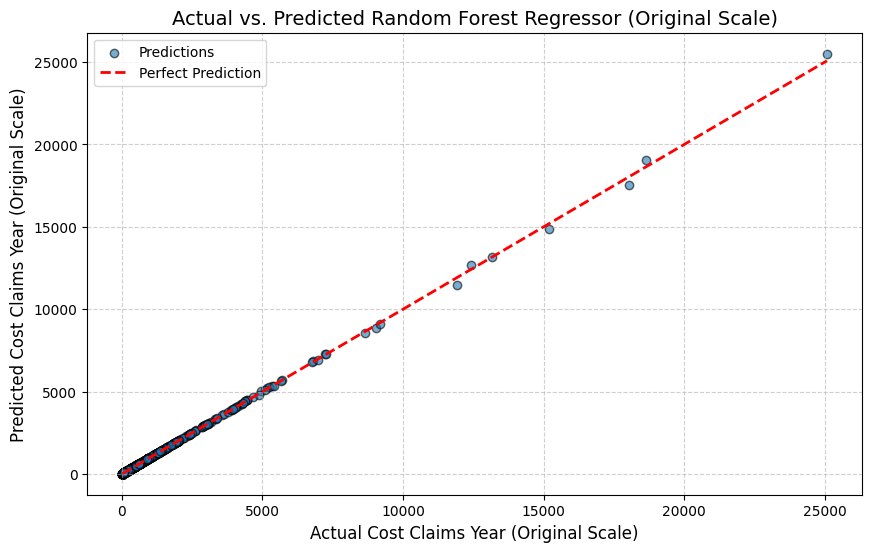

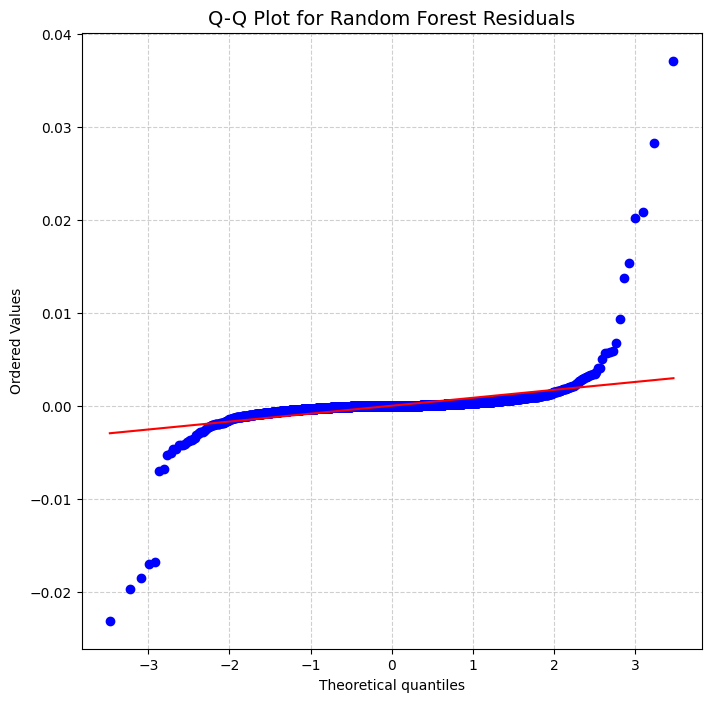

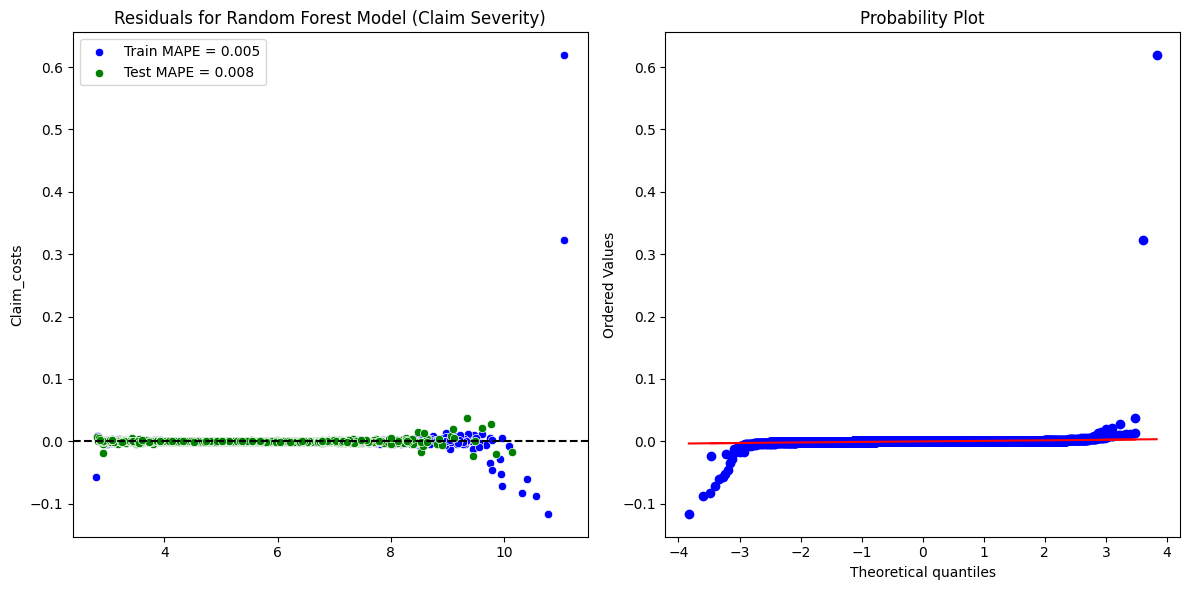

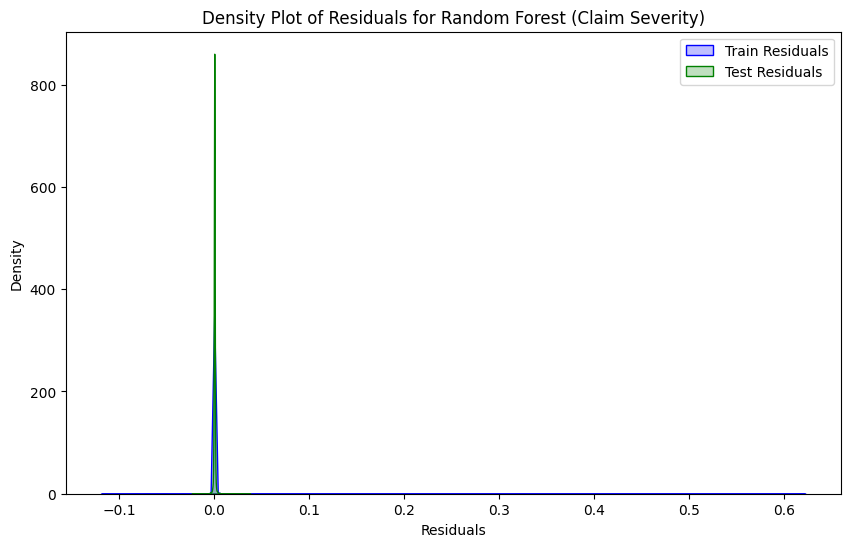

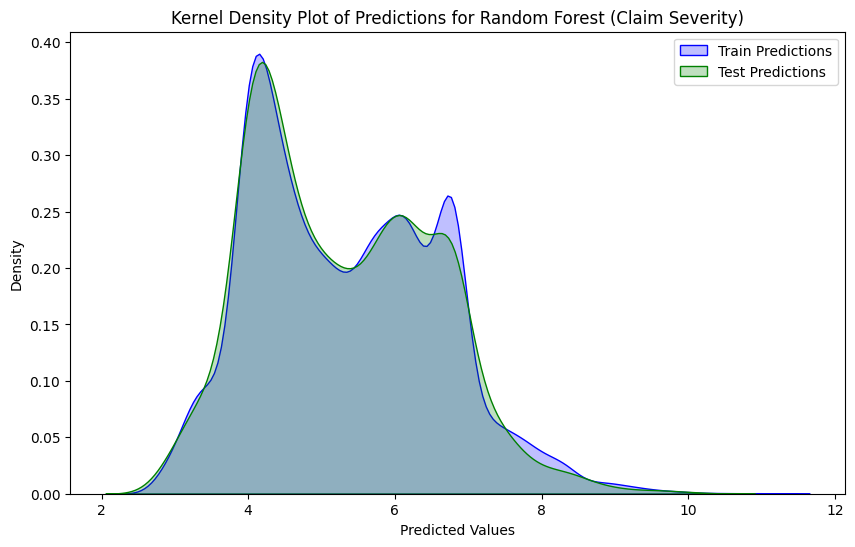

High leverage points IDs: [22739, 22923, 48073, 45073, 19522, 33268, 45422, 35882, 23842, 43610, 52524, 6097, 40554, 229, 39406, 21975, 52454, 1833, 45171, 52741, 26672, 17150, 20251, 34212, 38733, 34116, 13080, 48503, 33726, 1925, 50609, 10402, 35779, 15673, 8128, 44986, 5555, 45009, 44828, 3770, 45197, 24334, 17551, 43696, 48216, 38539, 51025, 38585, 11687, 38401]
High Cook's distance points IDs: [37039, 21388, 19522, 33268, 44038, 52528, 12397, 39127, 23842, 34980, 20596, 6165, 39149, 49338, 333, 46263, 6818, 29627, 34991, 52454, 2742, 26473, 43391, 17150, 35739, 34212, 38733, 34116, 10401, 21986, 13436, 44072, 48503, 35779, 2946, 5555, 30749, 23350, 22973, 33330, 32759, 38618, 26082, 17551, 35092, 38539, 51025, 38585, 8497, 27136]


RandomForestRegressor(min_samples_leaf=2, random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(random_state=42)
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

run_model_with_top_features_and_qq_plot(
    df_train=df_train, 
    df_test=df_test, 
    model=rf_model, 
    param_grid=rf_param_grid, 
    model_name="Random Forest"
)
#21 

In [10]:
rf = pd.read_csv("random_forest_train_notexpanded.csv")
rf[['y_pred_nolog', 'y_true_nolog']].describe()

,y_pred_nolog,y_true_nolog
count,10828.000000,10828.000000
mean,531.837905,537.530294
std,1595.071752,1918.199476
min,15.447354,14.530000
25%,67.249769,67.250000
50%,181.196342,181.215000
75%,548.077787,548.146250
max,63624.703458,118142.590000


In [11]:
rf = pd.read_csv("random_forest_test_notexpanded.csv")
rf[['y_pred_nolog', 'y_true_nolog']].describe()

,y_pred_nolog,y_true_nolog
count,2707.000000,2707.000000
mean,469.077945,469.195328
std,1117.749374,1117.439034
min,15.750003,15.863333
25%,67.110000,67.110000
50%,168.786328,168.820000
75%,504.316919,504.335000
max,25501.003493,25071.950000


Fold 1 Results:
  Mean Squared Error (MSE): 1.5382
  Mean Absolute Error (MAE): 1.0526
Fold 2 Results:
  Mean Squared Error (MSE): 1.5273
  Mean Absolute Error (MAE): 1.0451
Fold 3 Results:
  Mean Squared Error (MSE): 1.5003
  Mean Absolute Error (MAE): 1.0400
Fold 4 Results:
  Mean Squared Error (MSE): 1.5282
  Mean Absolute Error (MAE): 1.0402
Fold 5 Results:
  Mean Squared Error (MSE): 1.5495
  Mean Absolute Error (MAE): 1.0490

Best Parameters from Grid Search for Gradient Boosting:
{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 3, 'learning_rate': 0.1}


Gradient Boosting Cross-Validation Summary:
  Fold 1: MSE = 1.5382, MAE = 1.0526
  Fold 2: MSE = 1.5273, MAE = 1.0451
  Fold 3: MSE = 1.5003, MAE = 1.0400
  Fold 4: MSE = 1.5282, MAE = 1.0402
  Fold 5: MSE = 1.5495, MAE = 1.0490

Gradient Boosting Model Evaluation on Training Set:
Mean Squared Error (MSE - Training): 1.4367
Mean Absolute Error (MAE - Training, Log Transformed): 1.0138
R² Score (T

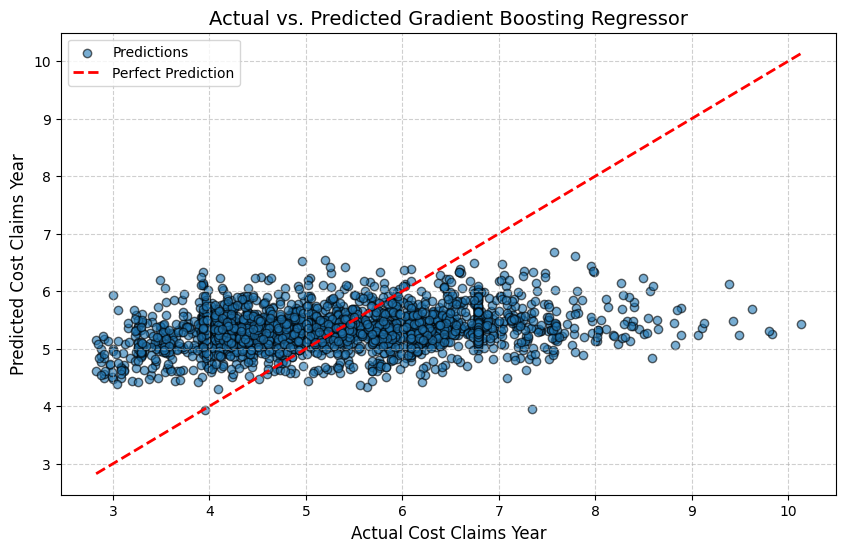

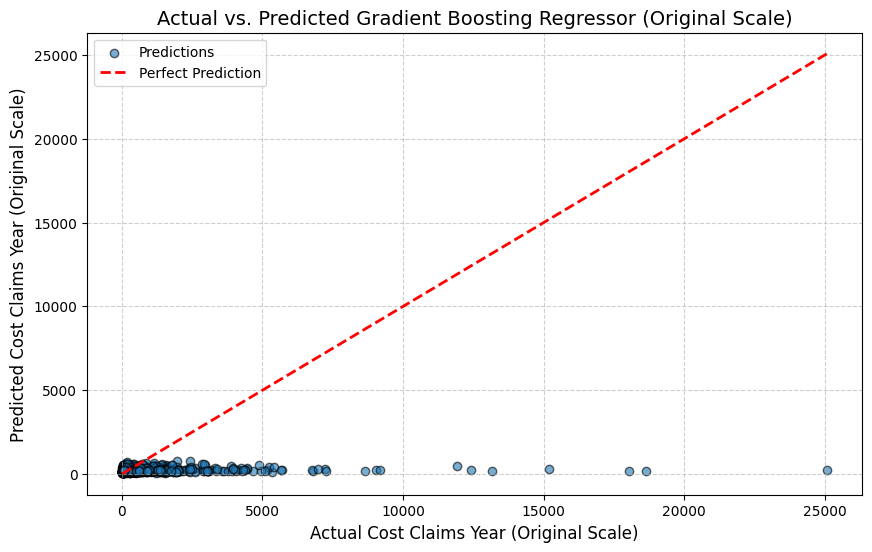

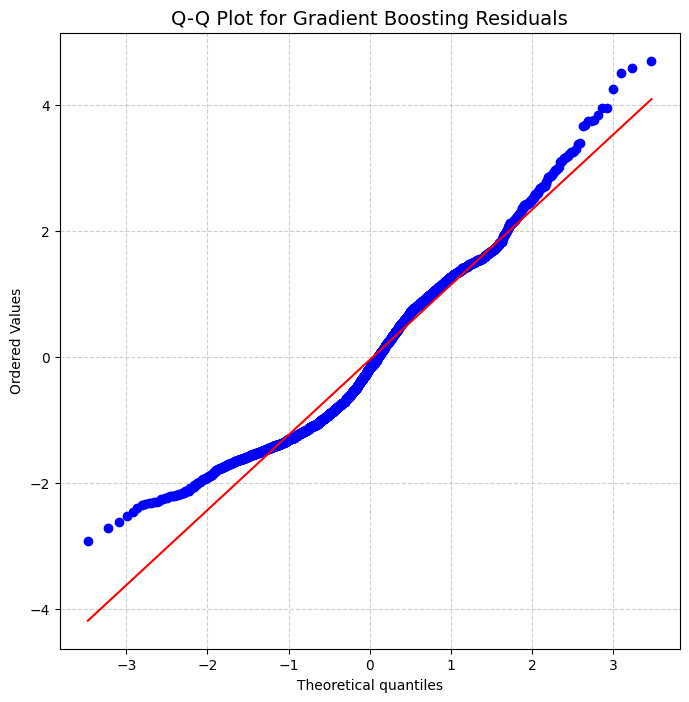

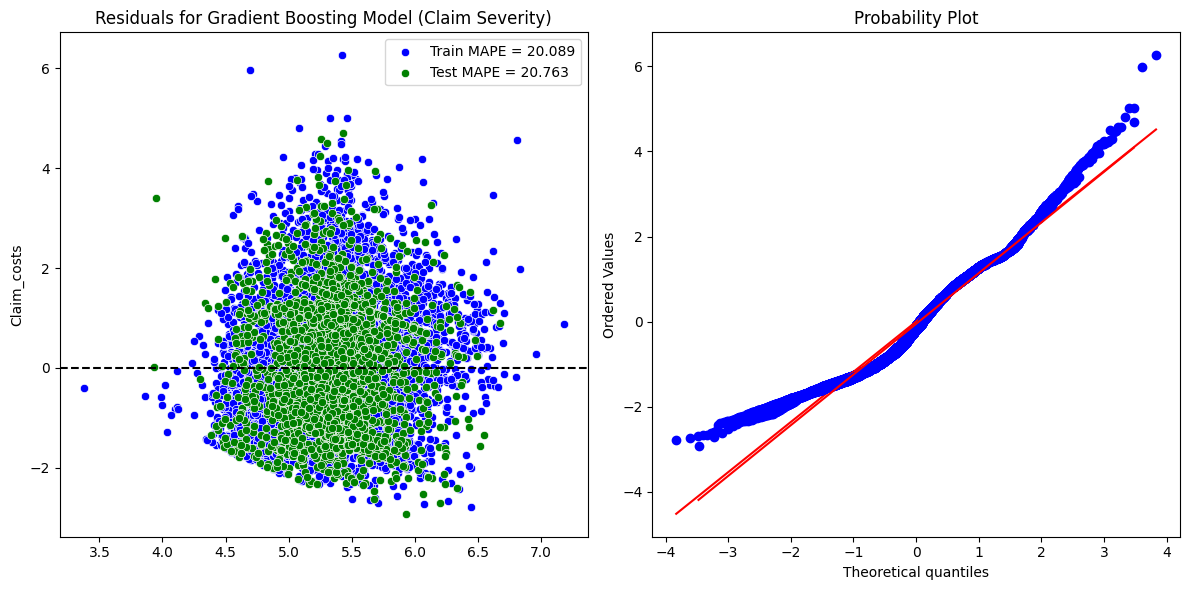

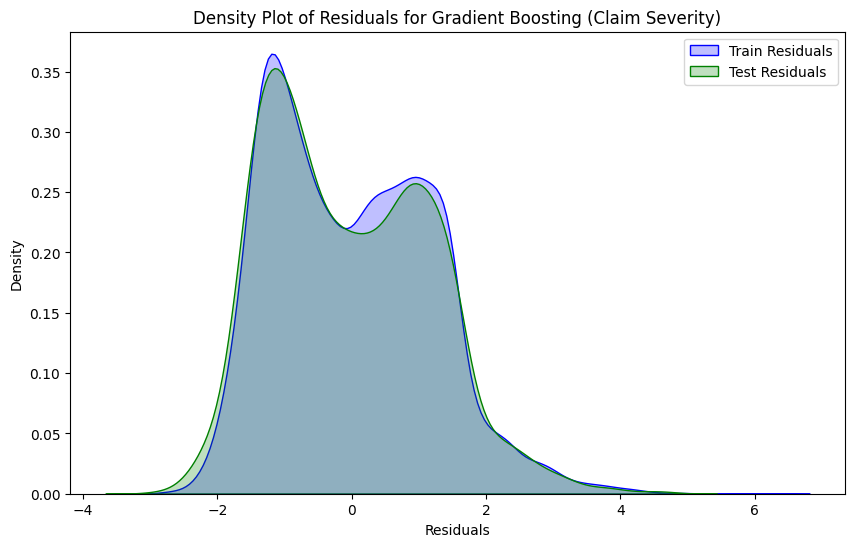

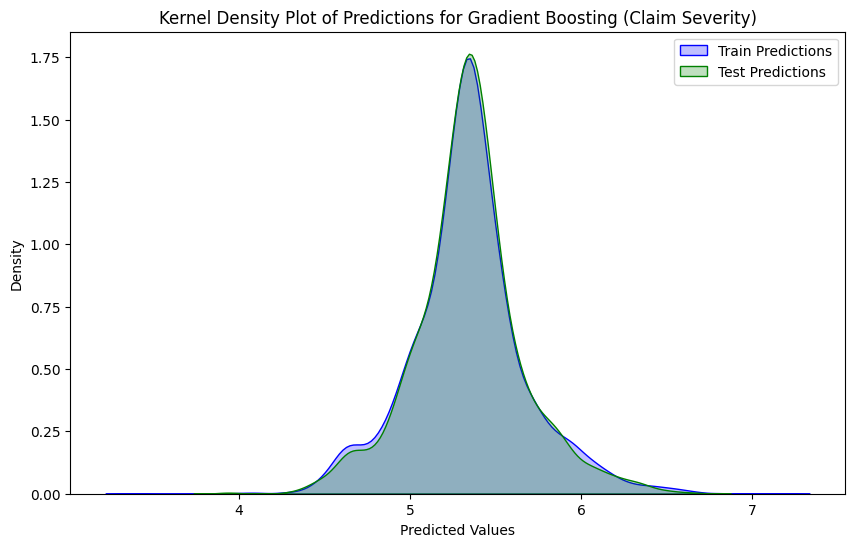

High leverage points IDs: [22739, 22923, 48073, 45073, 44933, 45422, 16574, 35882, 43610, 6097, 40554, 229, 39406, 263, 34463, 21975, 52454, 1833, 45171, 12591, 52741, 26672, 20251, 43445, 41608, 13080, 48503, 33726, 1925, 50609, 10402, 35779, 15673, 8128, 15643, 5555, 45009, 44828, 3770, 45197, 34207, 24334, 17551, 43696, 48216, 27996, 11687, 2407, 38401, 32165]
High Cook's distance points IDs: [22739, 37039, 37884, 48073, 33268, 20139, 12130, 4088, 44038, 52528, 12397, 16574, 21215, 14983, 23842, 9065, 44322, 52524, 20596, 6165, 24236, 229, 43891, 34594, 18061, 333, 10166, 24852, 33307, 45171, 2742, 16297, 52741, 43391, 5048, 17150, 30353, 20251, 34212, 38733, 34116, 33571, 7437, 2428, 10401, 8275, 7557, 21986, 36800, 765, 44072, 48503, 18382, 5712, 33726, 35779, 15673, 22966, 8128, 15643, 2946, 30077, 5555, 28040, 44828, 39185, 3770, 32759, 38618, 34207, 15933, 17030, 17551, 40810, 52528, 37027, 7583, 46147, 27996, 38539, 51025, 38585, 46559, 27289, 27061, 20777, 19896, 47937, 13400

GradientBoostingRegressor(min_samples_leaf=2, min_samples_split=5,
                          random_state=42)

In [16]:
from sklearn.ensemble import GradientBoostingRegressor

# Define Gradient Boosting Model and its hyperparameter grid
gbm_model = GradientBoostingRegressor(random_state=42)
gbm_param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Run the model with the specified function
run_model_with_top_features_and_qq_plot(
    df_train=df_train, 
    df_test=df_test, 
    model=gbm_model, 
    param_grid=gbm_param_grid, 
    model_name="Gradient Boosting"
)
# 14


In [14]:
gb = pd.read_csv("gradient_boosting_test.csv")
gb.describe()

,Distribution_channel,Seniority,Lapse,Payment,Premium,N_claims_history,R_Claims_history,Type_risk,Area,Second_driver,...,Type_fuel_D,Type_fuel_P,N_claims_year,ID,Claim_costs,y_true,y_pred,y_pred_nolog,y_true_nolog,residuals
count,2707.000000,2707.000000,2707.000000,2707.000000,2707.000000,2707.000000,2707.000000,2707.0,2707.000000,2707.000000,...,2707.000000,2707.000000,2707.000000,2707.000000,2707.000000,2707.000000,2707.000000,2707.000000,2707.000000,2707.000000
mean,0.016993,0.003844,0.015662,-0.008931,-0.025211,0.007611,-0.002652,0.0,-0.032244,0.038664,...,0.032178,-0.032178,0.000380,26978.957518,5.287710,5.287710,5.287733,468.687883,469.195328,-0.000023
std,1.000147,1.009524,1.073235,0.999057,0.962972,1.034652,1.042396,0.0,0.984931,1.033483,...,0.988699,0.988699,1.000318,15003.190049,1.242693,1.242693,1.242557,1107.703888,1117.439034,0.002289
min,-0.993740,-0.865634,-0.333790,-0.885688,-2.018069,-0.807289,-1.310417,0.0,-0.644678,-0.447114,...,-1.394558,-0.717073,-0.795082,32.000000,2.825142,2.825142,2.838426,16.088839,15.863333,-0.045502
25%,-0.993740,-0.681480,-0.333790,-0.885688,-0.592865,-0.555268,-0.697295,0.0,-0.644678,-0.447114,...,-1.394558,-0.717073,-0.795082,14323.500000,4.221124,4.221124,4.221182,67.113923,67.110000,-0.000628
50%,1.006300,-0.313171,-0.333790,-0.885688,-0.256649,-0.303248,-0.195650,0.0,-0.644678,-0.447114,...,0.717073,-0.717073,-0.795082,27037.000000,5.134739,5.134739,5.134401,168.762554,168.820000,-0.000031
75%,1.006300,0.239292,-0.333790,1.129066,0.245632,0.326802,0.361733,0.0,1.551162,-0.447114,...,0.717073,1.394558,0.578207,39416.500000,6.225222,6.225222,6.225273,504.361387,504.335000,0.000482
max,1.006300,6.132230,12.915023,1.129066,7.293387,11.289681,22.623618,0.0,1.551162,2.236564,...,0.717073,1.394558,1.951496,53429.000000,10.129545,10.129545,10.085979,24003.080263,25071.950000,0.043566


### SHAP defined

c:\Users\Guest Hoefkestraat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 1 is smaller than n_iter=10. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Running SHAP Analysis for Gradient Boosting...


 97%|=================== | 15209/15659 [00:11<00:00]       


SHAP Summary Plot for Gradient Boosting Regressor


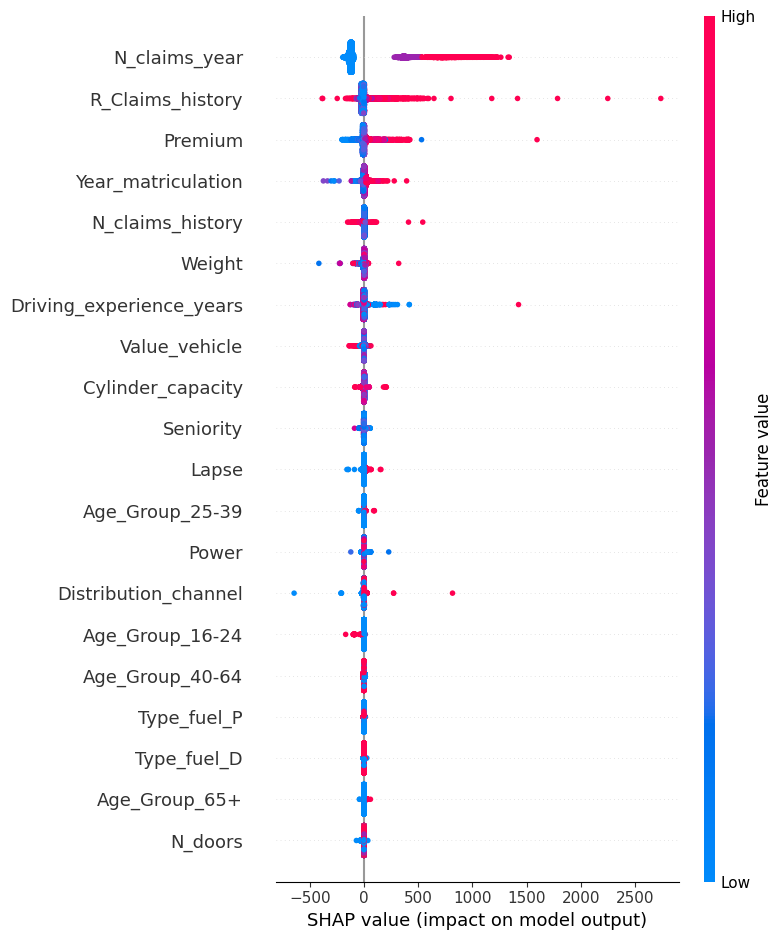


SHAP Bar Plot for Gradient Boosting Regressor


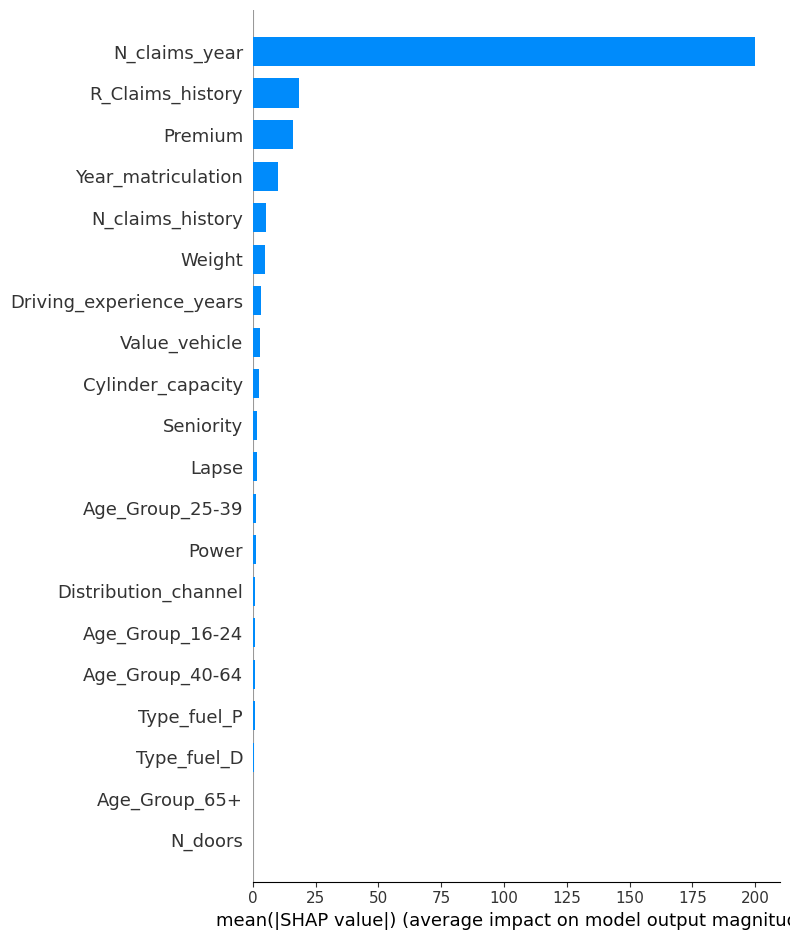


SHAP Dependence Plot for N_claims_year in Gradient Boosting Regressor


TypeError: loop of ufunc does not support argument 0 of type Explanation which has no callable conjugate method

In [13]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV

# Load datasets
df_train = pd.read_csv("train_set_stan_40K.csv")
df_test = pd.read_csv("test_set_stan_40K.csv")

# Separate features and target variable
X_train = df_train.drop(columns=['Cost_claims_year', "ID"])
y_train = df_train['Cost_claims_year']
X_test = df_test.drop(columns=['Cost_claims_year', "ID"])
y_test = df_test['Cost_claims_year']

# Define models
xgb_model = XGBRegressor(objective='reg:squarederror', random_state=42)
rf_model = RandomForestRegressor(random_state=42)
gb_model = GradientBoostingRegressor(random_state=42)

# Define hyperparameter grids

gb_param_grid = {
    'n_estimators': [100],
    'learning_rate': [0.1],
    'max_depth': [3],
    'min_samples_split': [5],
    'min_samples_leaf': [2]
}

# Function to perform hyperparameter tuning
def tune_model(model, param_grid, X_train, y_train):
    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_grid,
        n_iter=10,
        cv=5,
        scoring='neg_mean_squared_error',
        n_jobs=-1,
        random_state=42
    )
    search.fit(X_train, y_train)
    return search.best_estimator_

best_gb = tune_model(gb_model, gb_param_grid, X_train, y_train)

# SHAP Analysis Function
def shap_analysis(model, X_train, X_test, model_name):
    explainer = shap.Explainer(model, X_train)
    shap_values = explainer(X_test)

    # Summary Plot
    print(f"\nSHAP Summary Plot for {model_name}")
    shap.summary_plot(shap_values, X_test)

    # Bar Plot
    print(f"\nSHAP Bar Plot for {model_name}")
    shap.summary_plot(shap_values, X_test, plot_type="bar")

    # Dependence Plot for Top Feature
    top_feature = X_test.columns[np.abs(shap_values.values).mean(axis=0).argmax()]
    print(f"\nSHAP Dependence Plot for {top_feature} in {model_name}")
    shap.dependence_plot(top_feature, shap_values, X_test)


print("Running SHAP Analysis for Gradient Boosting...")
shap_analysis(best_gb, X_train, X_test, "Gradient Boosting Regressor")


c:\Users\Guest Hoefkestraat\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Calculating SHAP values for Random Forest...



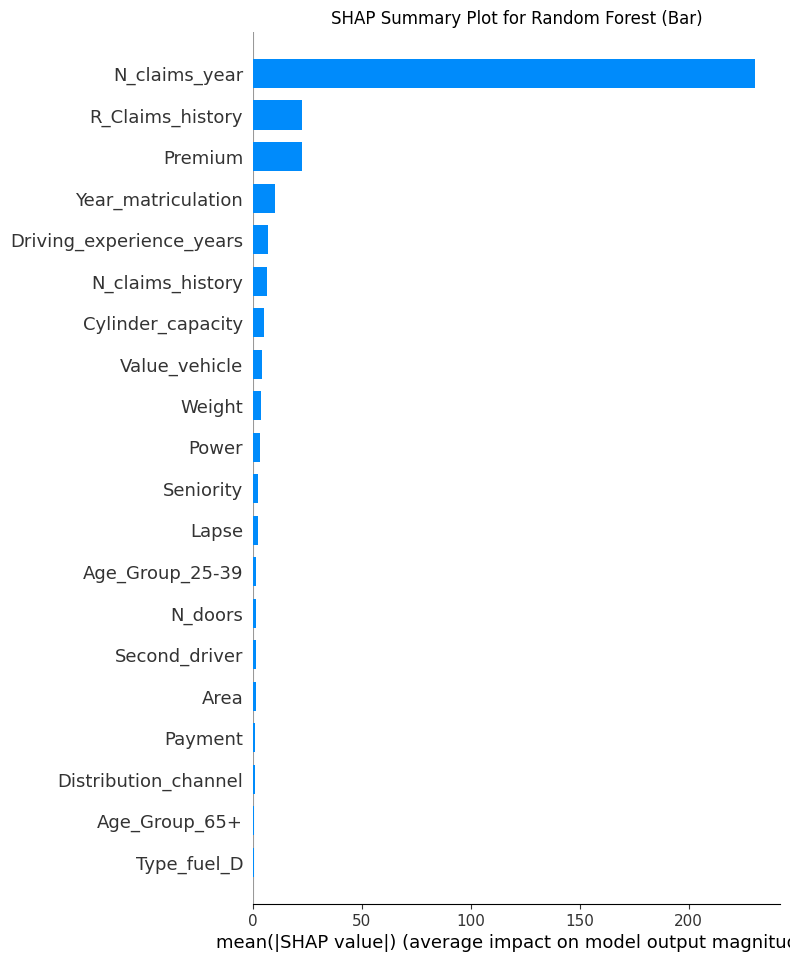

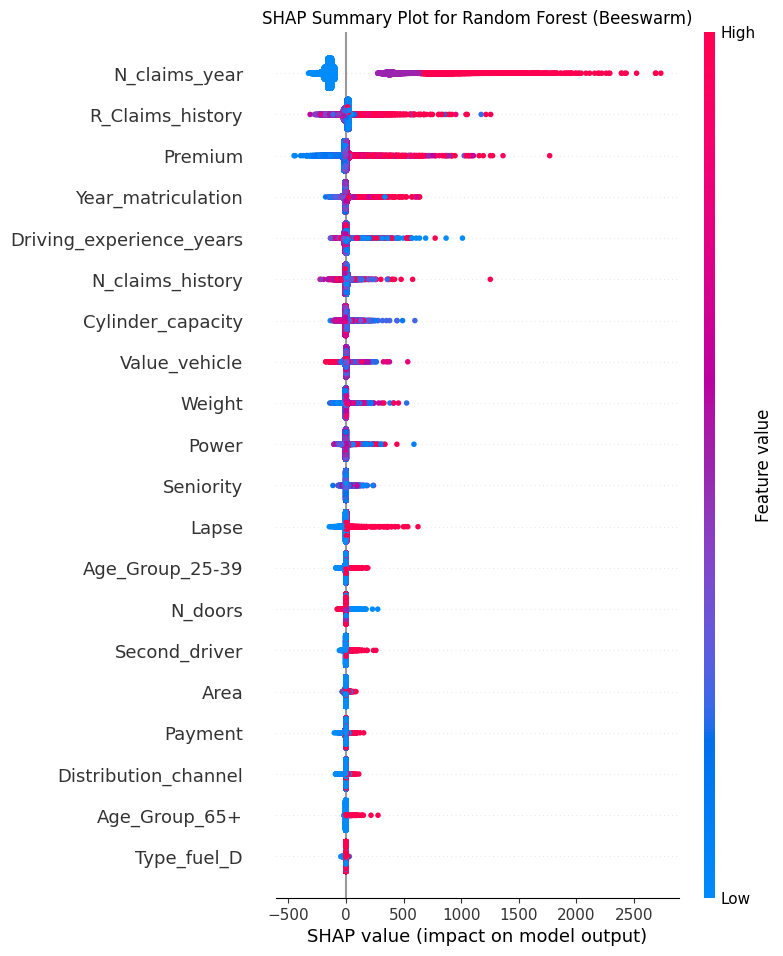


Calculating SHAP values for XGBoost...



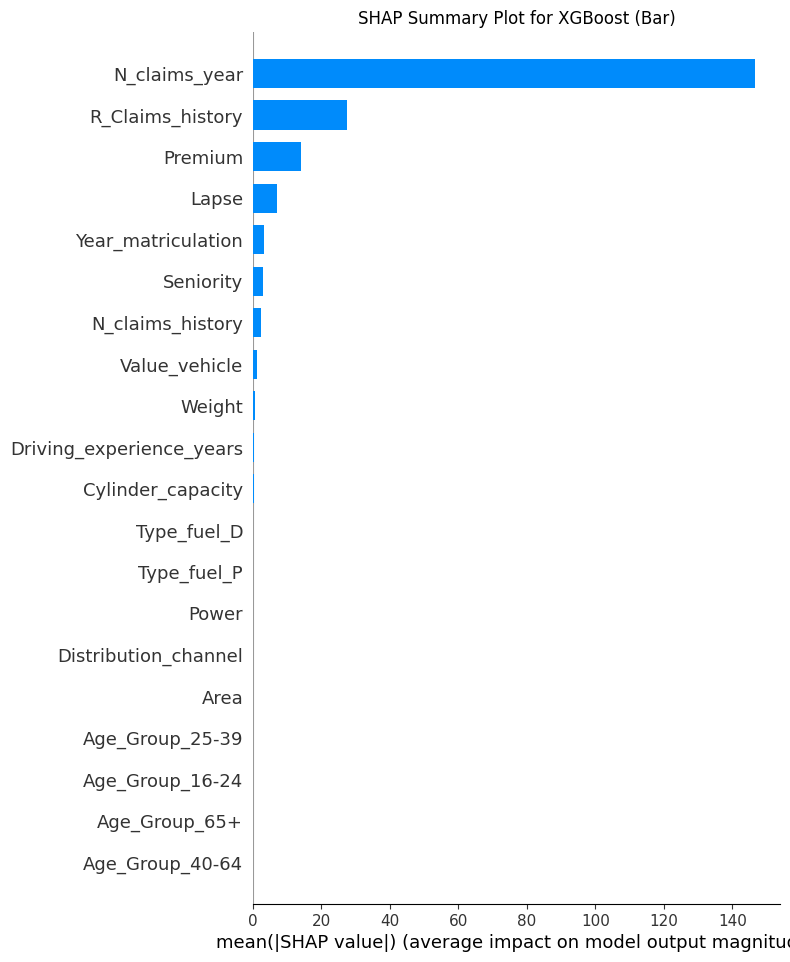

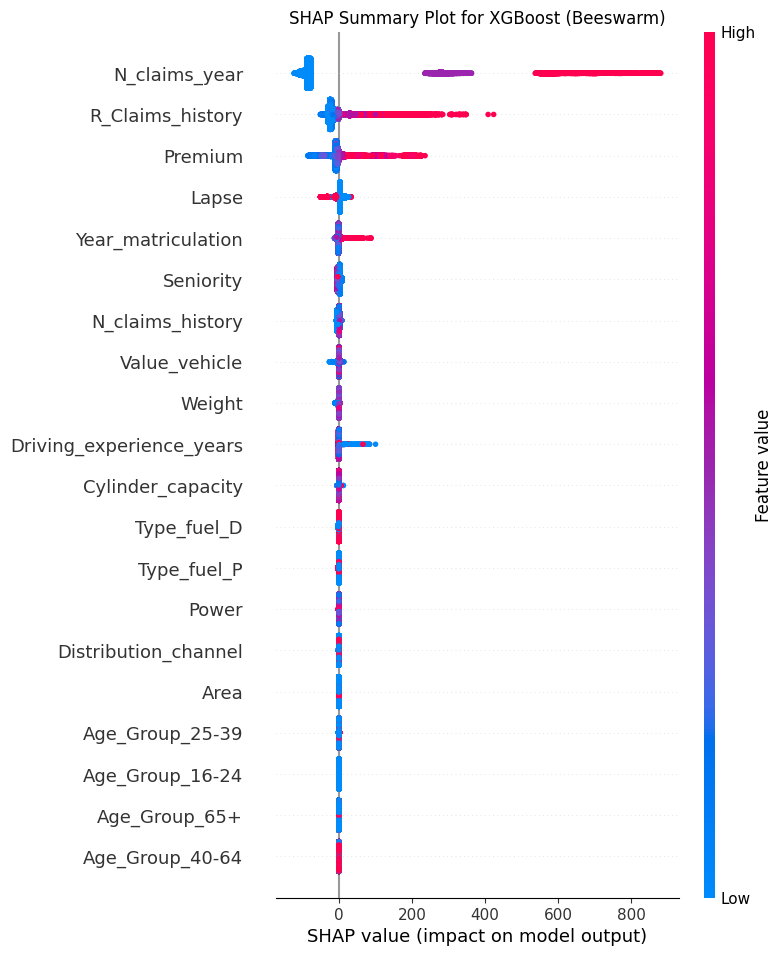

In [ ]:

import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

# Load datasets
df_train = pd.read_csv("train_set_stan_40K.csv")
df_test = pd.read_csv("test_set_stan_40K.csv")

# Separate features and target variable
X_train = df_train.drop(columns=['Cost_claims_year', "ID"])
y_train = df_train['Cost_claims_year']
X_test = df_test.drop(columns=['Cost_claims_year', "ID"])
y_test = df_test['Cost_claims_year']


# Function to calculate and plot SHAP values, including beeswarm plot for a given model
def calculate_shap_values_with_beeswarm(model, X, model_name):
    print(f"\nCalculating SHAP values for {model_name}...\n")
    
    # Use TreeExplainer for faster computation with tree-based models
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X, check_additivity=False)

    # Bar summary plot of SHAP values (average absolute values)
    shap.summary_plot(shap_values, X, plot_type="bar", show=False)
    plt.title(f"SHAP Summary Plot for {model_name} (Bar)")
    plt.show()

    # Dot summary plot of SHAP values (beeswarm)
    shap.summary_plot(shap_values, X, show=False)
    plt.title(f"SHAP Summary Plot for {model_name} (Beeswarm)")
    plt.show()

# Train models for SHAP analysis with beeswarm
def train_model_and_shap_with_beeswarm(X_train, y_train, X_test, model, model_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Display SHAP values with beeswarm plot
    calculate_shap_values_with_beeswarm(model, X_train, model_name)
    
    return model

# Instantiate models with default or tuned hyperparameters
# Gradient Boosting model with specified hyperparameters
#gbm_model = GradientBoostingRegressor(n_estimators=100, min_samples_split=5, learning_rate=0.1, max_depth=5, random_state=42)
rf_model = RandomForestRegressor(n_estimators=50, max_depth=10, min_samples_split=2, min_samples_leaf=4, random_state=42)
xgb_model = XGBRegressor(subsample = 0.8, n_estimators=200, learning_rate=0.01, max_depth=3, colsample_bytree = 0.8, random_state=42)

# Train models and generate SHAP values with beeswarm plot
#gbm_trained = train_model_and_shap_with_beeswarm(X_train, y_train, X_test, gbm_model, "Gradient Boosting Machine")
rf_trained = train_model_and_shap_with_beeswarm(X_train, y_train, X_test, rf_model, "Random Forest")
xgb_trained = train_model_and_shap_with_beeswarm(X_train, y_train, X_test, xgb_model, "XGBoost")



### Burota defined 

In [14]:
# Import necessary libraries
import pandas as pd
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from boruta import BorutaPy

df_train = pd.read_csv("train_set_stan_40K.csv")
df_test = pd.read_csv("test_set_stan_40K.csv")

# Separate features and target variable
X_train = df_train.drop(columns=['Cost_claims_year', "ID"])
y_train = df_train['Cost_claims_year']
X_test = df_test.drop(columns=['Cost_claims_year', "ID"])
y_test = df_test['Cost_claims_year']


# ========================
# Boruta Feature Selection Function
# ========================
def boruta_feature_selection(X_train, y_train, model_type="RandomForest"):
    """
    Perform Boruta feature selection using a specified model.

    Args:
        X_train (pd.DataFrame): Training features.
        y_train (pd.Series): Target variable.
        model_type (str): Model type ('RandomForest', 'GradientBoosting', or 'XGBoost').

    Returns:
        Tuple: (Selected features DataFrame, List of selected feature names, DataFrame of feature rankings).
    """
    # Select the base model for Boruta
    if model_type == "RandomForest":
        base_model = RandomForestRegressor(n_estimators=50, max_depth=10, min_samples_split=2, min_samples_leaf=4, random_state=42)
    elif model_type == "GradientBoosting":
        base_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, min_samples_leaf=2, min_samples_split=5, random_state=42)
    elif model_type == "XGBoost":
        base_model = XGBRegressor(subsample = 0.8, n_estimators=200, learning_rate=0.01, max_depth=3, colsample_bytree = 0.8, random_state=42)
    else:
        raise ValueError("Invalid model type. Choose either 'RandomForest', 'GradientBoosting', or 'XGBoost'")


    # Initialize Boruta with the tuned model
    boruta_selector = BorutaPy(
        estimator=base_model,
        n_estimators='auto',
        random_state=42,
        verbose=2
    )
    
    # Fit Boruta selector on the entire dataset
    boruta_selector.fit(X_train.values, y_train.values)
    
    # Extract selected features
    selected_features = X_train.columns[boruta_selector.support_].tolist()
    print(f"Selected Features by Boruta ({model_type}): {selected_features}")

    # Create a DataFrame for feature rankings
    feature_ranking = pd.DataFrame({
        'Feature': X_train.columns,
        'Ranking': boruta_selector.ranking_
    }).sort_values(by='Ranking')  # Sort by ranking (1 is the best rank)
    
    print(f"\nFeature Rankings by Boruta ({model_type}):")
    print(feature_ranking)
    
    return X_train[selected_features], selected_features, feature_ranking

# ========================
# Execute Boruta Feature Selection
# ========================

# Boruta for Random Forest
print("Executing Boruta for Random Forest...")
X_train_rf, selected_features_rf, rf_feature_ranking = boruta_feature_selection(X_train, y_train, model_type="RandomForest")

# Boruta for Gradient Boosting
print("\nExecuting Boruta for Gradient Boosting...")
X_train_gbm, selected_features_gbm, gbm_feature_ranking = boruta_feature_selection(X_train, y_train, model_type="GradientBoosting")

# Boruta for XGBoost
print("\nExecuting Boruta for XGBoost...")
X_train_xgb, selected_features_xgb, xgb_feature_ranking = boruta_feature_selection(X_train, y_train, model_type="XGBoost")


Executing Boruta for Random Forest...
Iteration: 	1 / 100
Confirmed: 	0
Tentative: 	24
Rejected: 	0
Iteration: 	2 / 100
Confirmed: 	0
Tentative: 	24
Rejected: 	0
Iteration: 	3 / 100
Confirmed: 	0
Tentative: 	24
Rejected: 	0
Iteration: 	4 / 100
Confirmed: 	0
Tentative: 	24
Rejected: 	0
Iteration: 	5 / 100
Confirmed: 	0
Tentative: 	24
Rejected: 	0
Iteration: 	6 / 100
Confirmed: 	0
Tentative: 	24
Rejected: 	0
Iteration: 	7 / 100
Confirmed: 	0
Tentative: 	24
Rejected: 	0
Iteration: 	8 / 100
Confirmed: 	2
Tentative: 	1
Rejected: 	21
Iteration: 	9 / 100
Confirmed: 	2
Tentative: 	1
Rejected: 	21
Iteration: 	10 / 100
Confirmed: 	2
Tentative: 	1
Rejected: 	21
Iteration: 	11 / 100
Confirmed: 	2
Tentative: 	1
Rejected: 	21
Iteration: 	12 / 100
Confirmed: 	2
Tentative: 	1
Rejected: 	21
Iteration: 	13 / 100
Confirmed: 	2
Tentative: 	1
Rejected: 	21
Iteration: 	14 / 100
Confirmed: 	2
Tentative: 	1
Rejected: 	21
Iteration: 	15 / 100
Confirmed: 	2
Tentative: 	1
Rejected: 	21
Iteration: 	16 / 100
Confi

In [21]:
# Define the top 10 features from both Boruta plots
top_10_gb = [
"N_claims_year",
"R_Claims_history",
"Premium",
"Driving_experience_years",
"Weight",
"N_claims_history",
"Year_matriculation",
"Power",
"Value_vehicle",
"Cylinder_capacity"]


top_10_rf = [
"N_claims_year",
"Premium",
"R_Claims_history",
"Driving_experience_years",
"Year_matriculation",
"Value_vehicle",
"Weight",
"Power",
"Cylinder_capacity",
"N_claims_history"

]

top_10_xgb = [
"N_claims_year",
"Premium",
"Lapse",
"Driving_experience_years",
"Age_Group_25-39",
"R_Claims_history",
"Cylinder_capacity",
"Year_matriculation",
"Weight",
"Seniority"
]

# Convert lists to sets for easier comparison
set_rf = set(top_10_rf)
set_xgb = set(top_10_xgb)
set_gb = set(top_10_gb)

# Find common features across all three models
common_features_all = set_rf.intersection(set_xgb).intersection(set_gb)

# Find features unique to each model
unique_to_rf = set_rf - (set_xgb.union(set_gb))
unique_to_xgb = set_xgb - (set_rf.union(set_gb))
unique_to_gb = set_gb - (set_rf.union(set_xgb))

# Find features shared between any two models
common_rf_xgb = set_rf.intersection(set_xgb) - set_gb
common_rf_gb = set_rf.intersection(set_gb) - set_xgb
common_xgb_gb = set_xgb.intersection(set_gb) - set_rf

# Print the differences
print("Common Features Across All Models:", common_features_all)
print("Unique to Random Forest:", unique_to_rf)
print("Unique to XGBoost:", unique_to_xgb)
print("Unique to Gradient Boosting:", unique_to_gb)
print("Features Common to Random Forest and XGBoost:", common_rf_xgb)
print("Features Common to Random Forest and Gradient Boosting:", common_rf_gb)
print("Features Common to XGBoost and Gradient Boosting:", common_xgb_gb)



Common Features Across All Models: {'Year_matriculation', 'Weight', 'Driving_experience_years', 'R_Claims_history', 'Premium', 'N_claims_year', 'Cylinder_capacity'}
Unique to Random Forest: set()
Unique to XGBoost: {'Lapse', 'Seniority', 'Age_Group_25-39'}
Unique to Gradient Boosting: set()
Features Common to Random Forest and XGBoost: set()
Features Common to Random Forest and Gradient Boosting: {'Power', 'Value_vehicle', 'N_claims_history'}
Features Common to XGBoost and Gradient Boosting: set()


### Shap feature selection

In [15]:
# Define the top 10 features from both SHAP plots
top_10_gb = [
"N_claims_year",
"R_Claims_history",
"Premium",
"Year_matriculation",
"N_claims_history",
"Weight",
"Driving_experience_years",
"Value_vehicle",
"Cylinder_capacity",
"Seniority"]


top_10_rf = [
"N_claims_year",
"R_Claims_history",
"Premium",
"Year_matriculation",
"Driving_experience_years",
"N_claims_history",
"Cylinder_capacity",
"Value_vehicle",
"Weight",
"Power"
]

top_10_xgb = [
"N_claims_year",
"R_Claims_history",
"Premium",
"Lapse",
"Year_matriculation",
"Seniority",
"N_claims_history",
"Value_vehicle",
"Weight",
"Driving_experience_years"
]

# Convert lists to sets for easier comparison
set_rf = set(top_10_rf)
set_xgb = set(top_10_xgb)
set_gb = set(top_10_gb)

# Find common features across all three models
common_features_all = set_rf.intersection(set_xgb).intersection(set_gb)

# Find features unique to each model
unique_to_rf = set_rf - (set_xgb.union(set_gb))
unique_to_xgb = set_xgb - (set_rf.union(set_gb))
unique_to_gb = set_gb - (set_rf.union(set_xgb))

# Find features shared between any two models
common_rf_xgb = set_rf.intersection(set_xgb) - set_gb
common_rf_gb = set_rf.intersection(set_gb) - set_xgb
common_xgb_gb = set_xgb.intersection(set_gb) - set_rf

# Print the differences
print("Common Features Across All Models:", common_features_all)
print("Unique to Random Forest:", unique_to_rf)
print("Unique to XGBoost:", unique_to_xgb)
print("Unique to Gradient Boosting:", unique_to_gb)
print("Features Common to Random Forest and XGBoost:", common_rf_xgb)
print("Features Common to Random Forest and Gradient Boosting:", common_rf_gb)
print("Features Common to XGBoost and Gradient Boosting:", common_xgb_gb)



Common Features Across All Models: {'Value_vehicle', 'Year_matriculation', 'Weight', 'N_claims_history', 'Driving_experience_years', 'R_Claims_history', 'Premium', 'N_claims_year'}
Unique to Random Forest: {'Power'}
Unique to XGBoost: {'Lapse'}
Unique to Gradient Boosting: set()
Features Common to Random Forest and XGBoost: set()
Features Common to Random Forest and Gradient Boosting: {'Cylinder_capacity'}
Features Common to XGBoost and Gradient Boosting: {'Seniority'}


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

# Load datasets
df_train = pd.read_csv("train_set_stan_40K.csv")
df_test = pd.read_csv("test_set_stan_40K.csv")

# Ensure selected features are incorporated into the pipeline
def run_model_with_top_features_and_qq_plot(df_train, df_test, model, param_grid, selected_features, model_name="Model"):
    # Ensure extra columns like 'y_true' and 'y_pred' are not in df_test
    #df_test = df_test.drop(columns=['y_true', 'y_pred'], errors='ignore')

    # Filter selected features
    X_train = df_train[selected_features]  # Use only selected features for training
    y_train = df_train['Cost_claims_year']  # Adjust target column as necessary
    X_test = df_test[selected_features]  # Use only selected features for testing
    y_test = df_test['Cost_claims_year']

   # Nested cross-validation with hyperparameter tuning
    def hyperparameter_tuning_with_nested_cv(model, param_grid, X_train, y_train):
        inner_cv = KFold(n_splits=5, shuffle=True, random_state=42)
        grid_search = RandomizedSearchCV(
            estimator=model,
            param_distributions=param_grid,
            cv=inner_cv,
            n_jobs=-1,
            scoring='neg_mean_squared_error',
            random_state=42
        )
        grid_search.fit(X_train, y_train)
        best_model = grid_search.best_estimator_
        best_params = grid_search.best_params_

        # Cross-validation scores for each fold
        cv_results = cross_val_score(
            best_model, X_train, y_train, cv=inner_cv, scoring='neg_mean_squared_error'
        )
        print("\nMSE for each fold during CV:")
        for fold, mse in enumerate(-cv_results, start=1):  # Negate the negative MSE
            print(f"  Fold {fold}: MSE = {mse:.4f}")
        print(f"Mean CV MSE: {(-cv_results.mean()):.4f}")

        return best_model, best_params

    # Run nested CV and get the best model
    best_model, best_params = hyperparameter_tuning_with_nested_cv(
        model, param_grid, X_train, y_train
    )

    print(f"\nBest Parameters from Grid Search for {model_name}:\n{best_params}\n")

    # Evaluate the model on the full training and testing sets
    y_pred_train = best_model.predict(X_train)
    y_pred_test = best_model.predict(X_test)
    residuals_train = y_train - y_pred_train
    residuals_test = y_test - y_pred_test

    mse_train = mean_squared_error(y_train, y_pred_train)
    mae_train = mean_absolute_error(y_train, y_pred_train)
    r2_train = r2_score(y_train, y_pred_train)

    mse_test = mean_squared_error(y_test, y_pred_test)
    mae_test = mean_absolute_error(y_test, y_pred_test)
    r2_test = r2_score(y_test, y_pred_test)

    print(f"\n{model_name} Model Evaluation on Full Training Set:")
    print(f"  Mean Squared Error (MSE): {mse_train:.4f}")
    print(f"  Mean Absolute Error (MAE): {mae_train:.4f}")
    print(f"  R² Score: {r2_train:.4f}")

    print(f"\n{model_name} Model Evaluation on Full Test Set:")
    print(f"  Mean Squared Error (MSE): {mse_test:.4f}")
    print(f"  Mean Absolute Error (MAE): {mae_test:.4f}")
    print(f"  R² Score: {r2_test:.4f}")

    # Save predictions to CSV
    df_test['y_true'] = y_test
    df_test['y_pred'] = y_pred_test
    df_test.to_csv(f"{model_name.lower().replace(' ', '_')}_SHAP.csv", index=False)
    print(f"\nPredictions have been saved to '{model_name.lower().replace(' ', '_')}_SHAP.csv'.")

    # Plot Actual vs Predicted
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, y_pred_test, alpha=0.6, edgecolor='k', label='Predictions')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
    plt.title(f"Actual vs. Predicted {model_name} Regressor", fontsize=14)
    plt.xlabel("Actual Cost Claims Year", fontsize=12)
    plt.ylabel("Predicted Cost Claims Year", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.show()

    # Plot Q-Q Plot for Residuals
    plt.figure(figsize=(8, 8))
    stats.probplot(residuals_test, dist="norm", plot=plt)
    plt.title(f"Q-Q Plot for {model_name} Residuals", fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

    # Plot residuals and prediction density
    plot_residuals_and_qq(y_train, y_pred_train, y_test, y_pred_test, model_name)
    plot_residual_density(y_train, y_pred_train, y_test, y_pred_test, model_name)
    plot_prediction_kde(y_pred_train, y_pred_test, model_name)

    return best_model

def plot_residuals_and_qq(y_train, y_pred_train, y_test, y_pred_test, model_name):
    train_residuals = y_train - y_pred_train
    test_residuals = y_test - y_pred_test
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
    sns.scatterplot(x=y_pred_train, y=train_residuals, ax=ax1, color='blue', label=f'Train $R^2$ = {r2_score(y_train, y_pred_train):.3f}')
    sns.scatterplot(x=y_pred_test, y=test_residuals, ax=ax1, color='green', label=f'Test $R^2$ = {r2_score(y_test, y_pred_test):.3f}')
    ax1.axhline(0, color='black', linestyle='--')
    ax1.set_title(f'Residuals for {model_name} Model')
    ax1.set_xlabel("Predicted Values")
    ax1.set_ylabel("Residuals")
    stats.probplot(test_residuals, dist="norm", plot=ax2)
    ax2.set_title(f'Q-Q Plot for {model_name} Residuals')
    plt.tight_layout()
    plt.show()


def plot_prediction_kde(y_train_pred, y_test_pred, model_name):
    plt.figure(figsize=(10, 6))
    sns.kdeplot(y_train_pred, color='blue', fill=True, label='Train Predictions')
    sns.kdeplot(y_test_pred, color='green', fill=True, label='Test Predictions')
    plt.title(f'Kernel Density Plot of Predictions for {model_name}')
    plt.xlabel('Predicted Values')
    plt.legend()
    plt.show()


def plot_residual_density(y_train, y_pred_train, y_test, y_pred_test, model_name):
    train_residuals = y_train - y_pred_train
    test_residuals = y_test - y_pred_test
    plt.figure(figsize=(10, 6))
    sns.kdeplot(train_residuals, label='Train Residuals', color='blue')
    sns.kdeplot(test_residuals, label='Test Residuals', color='green')
    plt.title(f'Density Plot of Residuals for {model_name} Model')
    plt.xlabel('Residuals')
    plt.ylabel('Density')
    plt.legend()
    plt.show()


MSE for each fold during CV:
  Fold 1: MSE = 660576.6223
  Fold 2: MSE = 495936.9232
  Fold 3: MSE = 534858.1485
  Fold 4: MSE = 621733.1359
  Fold 5: MSE = 466165.0976
Mean CV MSE: 555853.9855

Best Parameters from Grid Search for XGBoost Regressor:
{'subsample': 0.8, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.8}


XGBoost Regressor Model Evaluation on Full Training Set:
  Mean Squared Error (MSE): 551500.4502
  Mean Absolute Error (MAE): 138.0231
  R² Score: 0.1560

XGBoost Regressor Model Evaluation on Full Test Set:
  Mean Squared Error (MSE): 542487.3067
  Mean Absolute Error (MAE): 143.4967
  R² Score: 0.1517

Predictions have been saved to 'xgboost_regressor_SHAP.csv'.


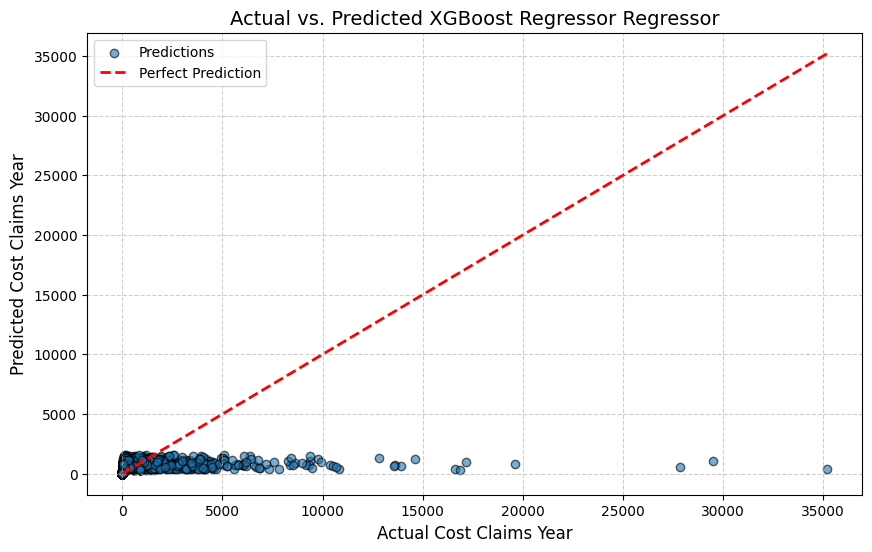

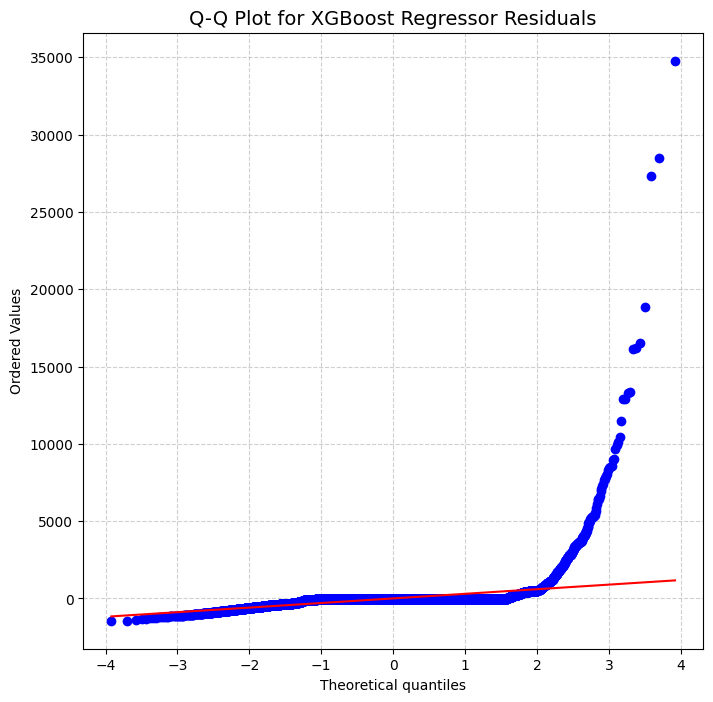

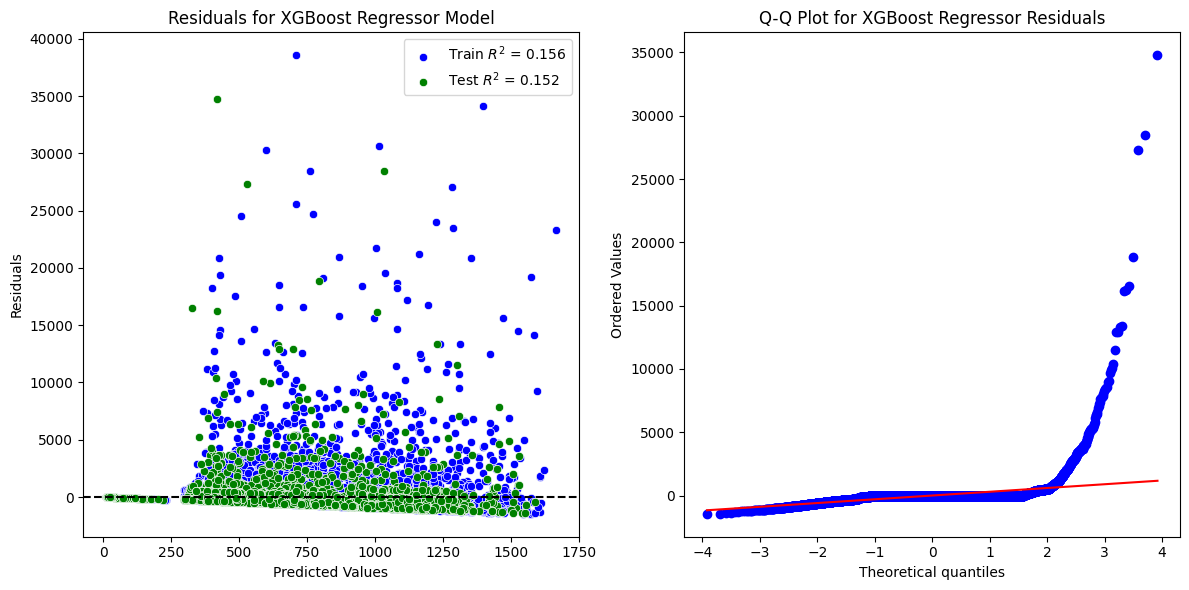

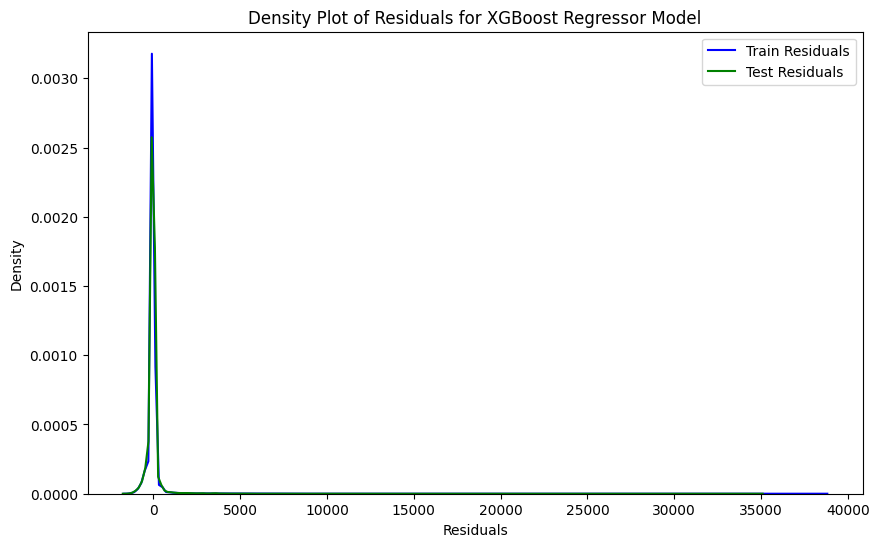

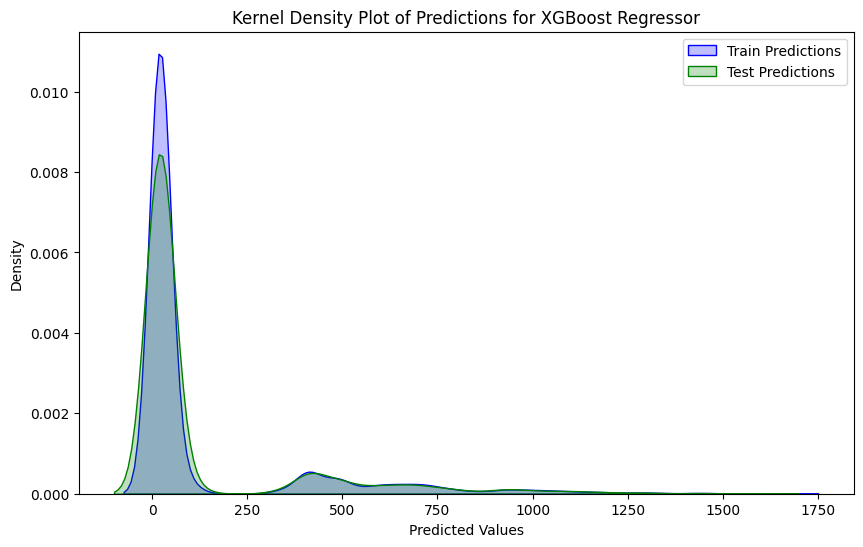

In [30]:

# Example: Selected features from Boruta or other feature selection methods
selected_features_xg = [
"N_claims_year",
"R_Claims_history",
"Premium",
"Lapse",
"Year_matriculation",
"Seniority",
"N_claims_history",
"Value_vehicle",
"Weight",
"Driving_experience_years"
]



# Define the XGBoost regressor
model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# Define the parameter grid for hyperparameter tuning
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Run the function
best_model = run_model_with_top_features_and_qq_plot(
    df_train=df_train,
    df_test=df_test,
    model=model,
    param_grid=param_grid,
    selected_features=selected_features_xg,  # Pass the selected features
    model_name="XGBoost Regressor"
)



MSE for each fold during CV:
  Fold 1: MSE = 661295.2783
  Fold 2: MSE = 496345.9149
  Fold 3: MSE = 534916.3352
  Fold 4: MSE = 621127.7536
  Fold 5: MSE = 466285.1668
Mean CV MSE: 555994.0897

Best Parameters from Grid Search for Random Forest:
{'subsample': 0.8, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.8}


Random Forest Model Evaluation on Full Training Set:
  Mean Squared Error (MSE): 551828.8989
  Mean Absolute Error (MAE): 138.4359
  R² Score: 0.1555

Random Forest Model Evaluation on Full Test Set:
  Mean Squared Error (MSE): 542403.0510
  Mean Absolute Error (MAE): 143.7098
  R² Score: 0.1518

Predictions have been saved to 'random_forest_SHAP.csv'.


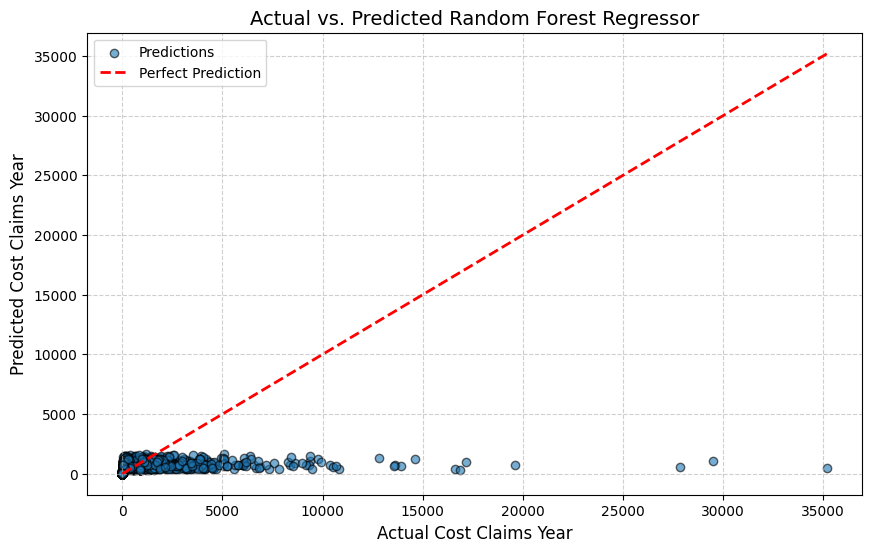

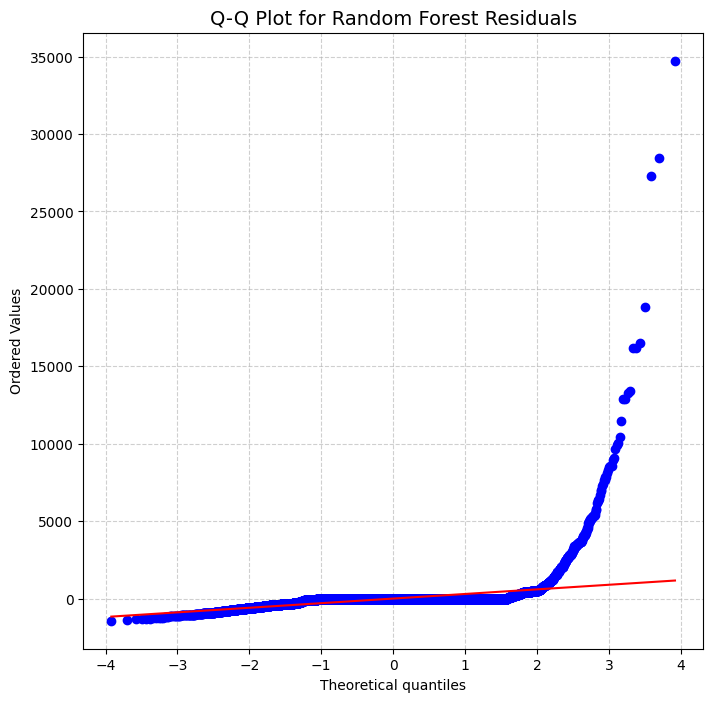

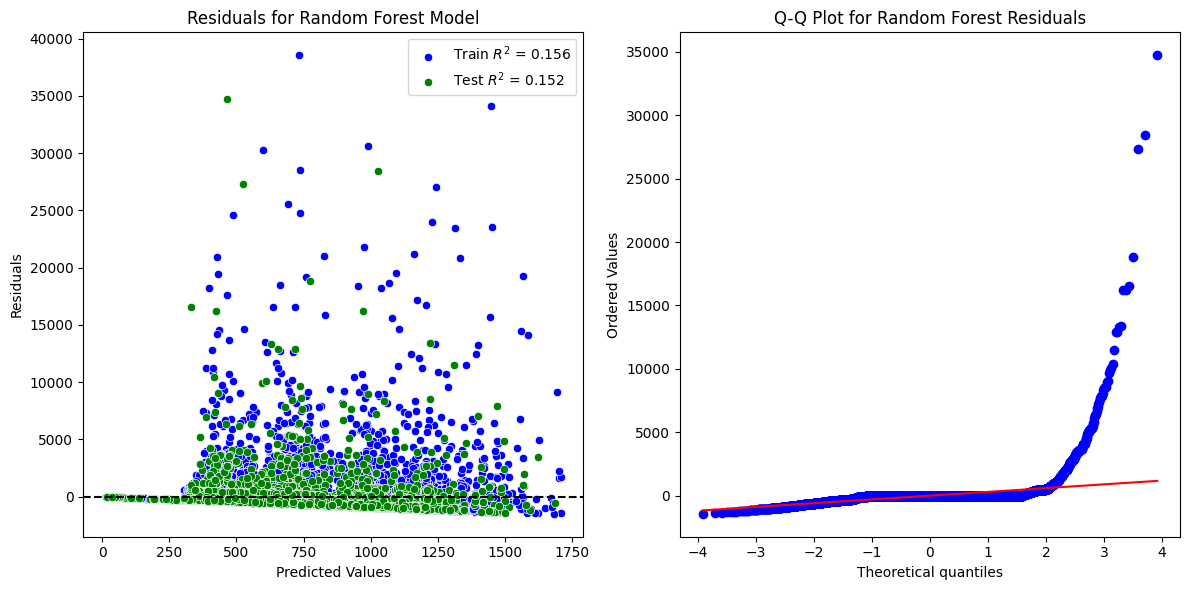

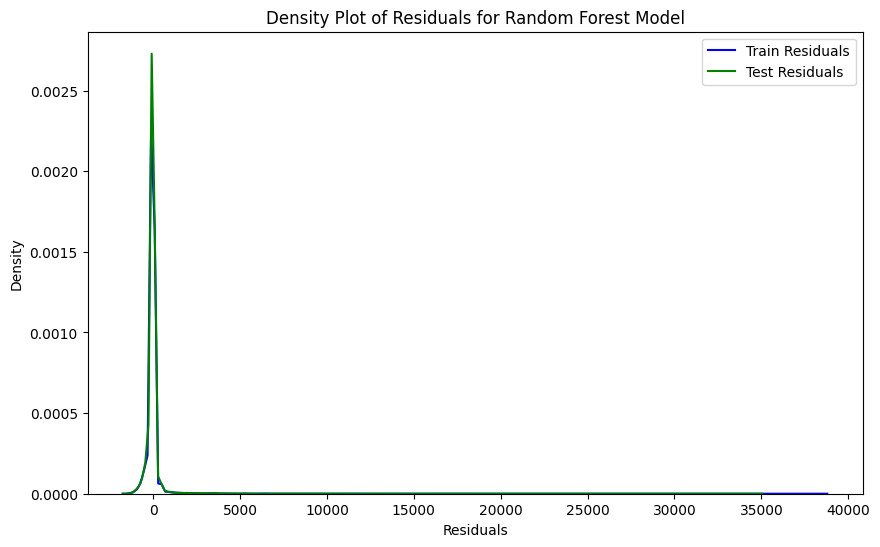

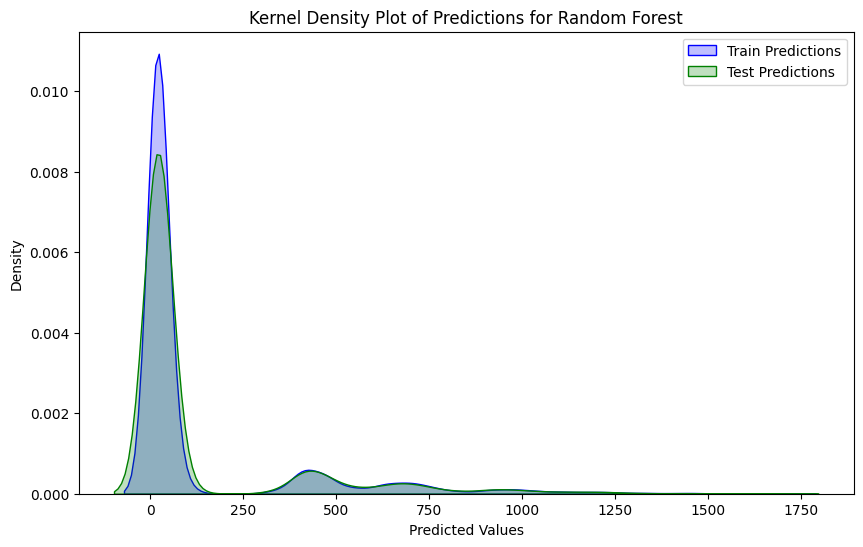

In [31]:
from sklearn.ensemble import RandomForestRegressor
# Example: Selected features from Boruta or other feature selection methods
selected_features_rf = [
"N_claims_year",
"R_Claims_history",
"Premium",
"Year_matriculation",
"Driving_experience_years",
"N_claims_history",
"Cylinder_capacity",
"Value_vehicle",
"Weight",
"Power"
]
rf_model = RandomForestRegressor(random_state=42)
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Run the function
best_model = run_model_with_top_features_and_qq_plot(
    df_train=df_train,
    df_test=df_test,
    model=model,
    param_grid=param_grid,
    selected_features=selected_features_rf,  
    model_name="Random Forest"
)
#8 mins 

In [34]:
import pandas as pd

gb_shap = pd.read_csv("gradient_boosting_SHAP.csv")
gb_summary = gb_shap[['y_true', 'y_pred']].describe()

print(f'\nGradient Boosting SHAP Summary:\n{gb_summary}')

xg_shap = pd.read_csv("xgboost_regressor_SHAP.csv")
xg_summary = xg_shap[['y_true', 'y_pred']].describe()
print(f'\nXGBoost Regressor SHAP Summary:\n{xg_summary}')

rf_shap = pd.read_csv("random_forest_SHAP.csv")
rf_summary = rf_shap[['y_true', 'y_pred']].describe()
print(f'\nRandom Forest SHAP Summary:\n{rf_summary}')


Gradient Boosting SHAP Summary:
             y_true        y_pred
count  15659.000000  15659.000000
mean     135.018277    129.848558
std      799.718784    256.923325
min        0.000000     14.194198
25%        0.000000     17.198711
50%        0.000000     17.445168
75%        0.000000     35.786779
max    35191.030000   1667.658300

XGBoost Regressor SHAP Summary:
             y_true        y_pred
count  15659.000000  15659.000000
mean     135.018277    129.845120
std      799.718784    258.164276
min        0.000000     11.179924
25%        0.000000     16.987839
50%        0.000000     17.456427
75%        0.000000     32.209755
max    35191.030000   1589.951000

Random Forest SHAP Summary:
             y_true        y_pred
count  15659.000000  15659.000000
mean     135.018277    129.785249
std      799.718784    256.528115
min        0.000000     14.066543
25%        0.000000     16.853725
50%        0.000000     17.261139
75%        0.000000     36.556135
max    35191.030000  


MSE for each fold during CV:
  Fold 1: MSE = 661307.5325
  Fold 2: MSE = 496390.8339
  Fold 3: MSE = 534740.2194
  Fold 4: MSE = 620910.7992
  Fold 5: MSE = 466240.9619
Mean CV MSE: 555918.0694

Best Parameters from Grid Search for Gradient Boosting:
{'subsample': 0.8, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.8}


Gradient Boosting Model Evaluation on Full Training Set:
  Mean Squared Error (MSE): 551769.5259
  Mean Absolute Error (MAE): 138.4101
  R² Score: 0.1556

Gradient Boosting Model Evaluation on Full Test Set:
  Mean Squared Error (MSE): 542457.5299
  Mean Absolute Error (MAE): 143.7613
  R² Score: 0.1518

Predictions have been saved to 'gradient_boosting_SHAP.csv'.


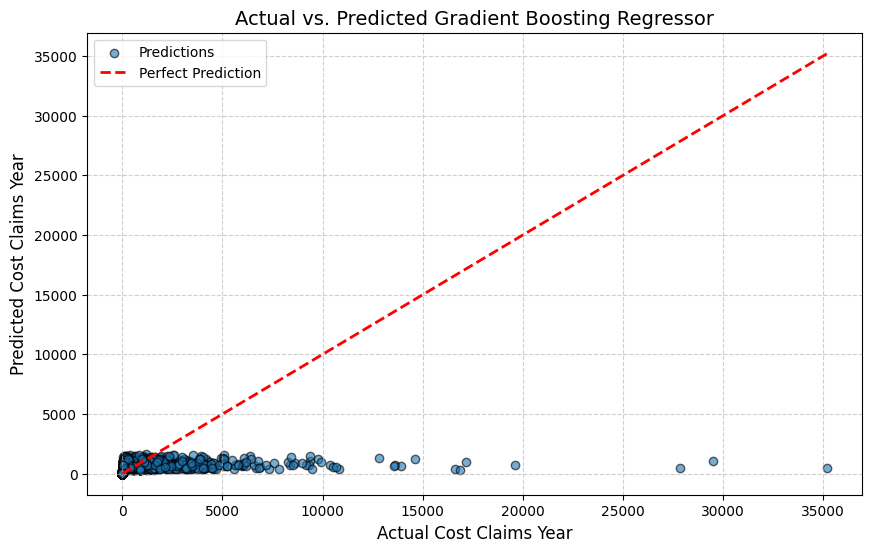

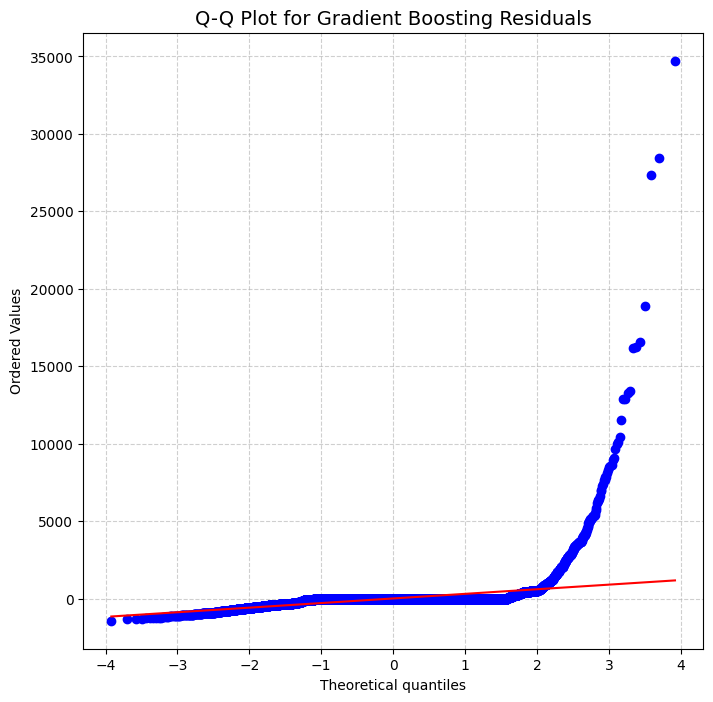

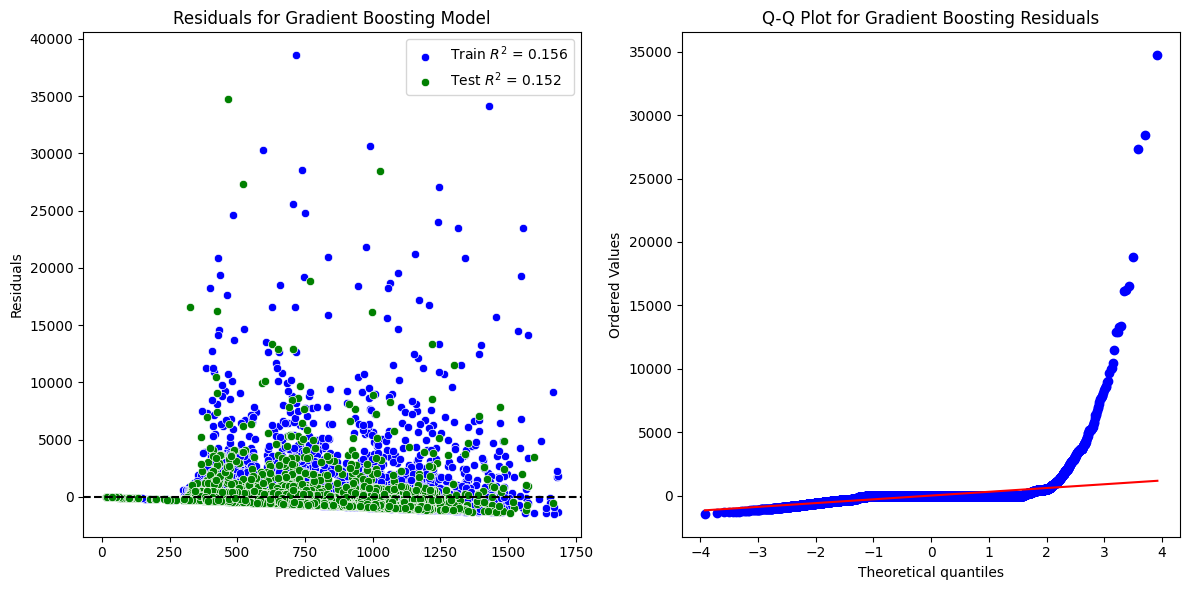

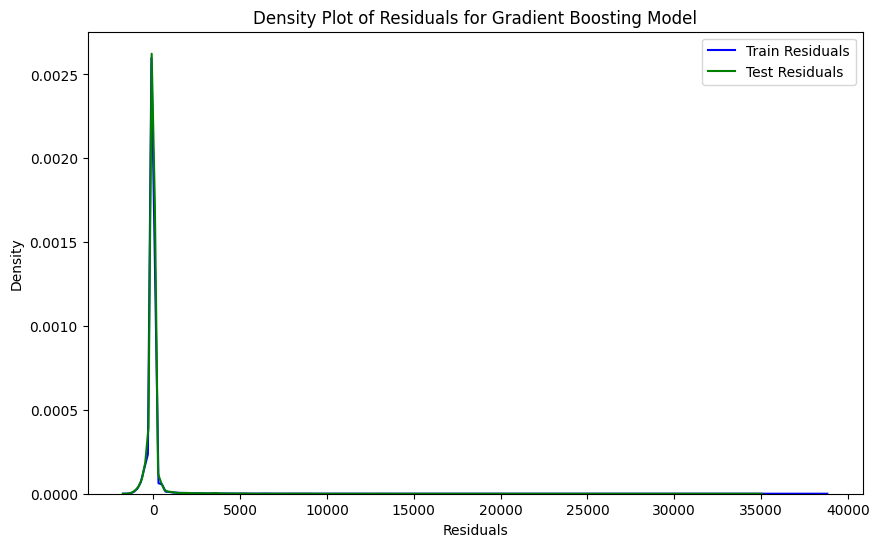

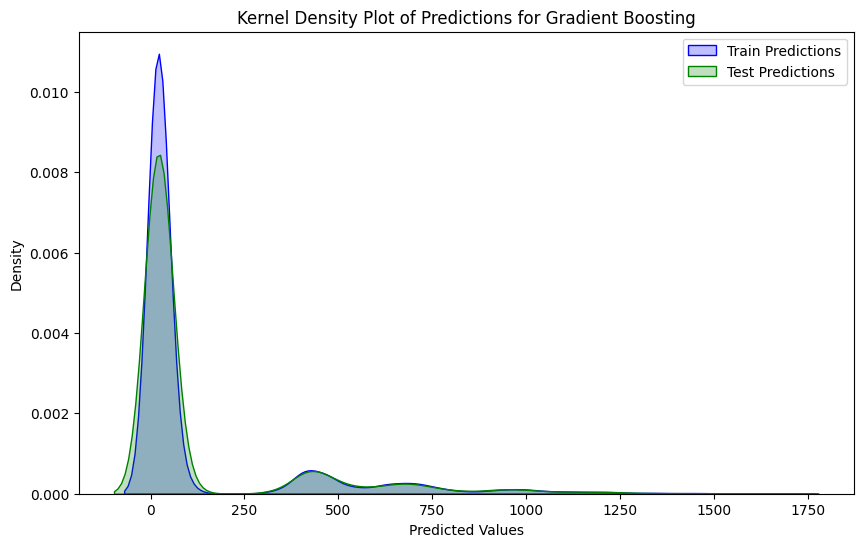

In [33]:
from sklearn.ensemble import GradientBoostingRegressor
selected_features_gb = [
"N_claims_year",
"R_Claims_history",
"Premium",
"Year_matriculation",
"N_claims_history",
"Weight",
"Driving_experience_years",
"Value_vehicle",
"Cylinder_capacity",
"Seniority"]

# Define Gradient Boosting Model and its hyperparameter grid
gbm_model = GradientBoostingRegressor(random_state=42)
gbm_param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Run the function
best_model = run_model_with_top_features_and_qq_plot(
    df_train=df_train,
    df_test=df_test,
    model=model,
    param_grid=param_grid,
    selected_features=selected_features_gb,  
    model_name="Gradient Boosting"
)


### Boruta feature selection 

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns


# Load datasets
df_train = pd.read_csv("train_set_stan_40K.csv")
df_test = pd.read_csv("test_set_stan_40K.csv")

# Ensure selected features are incorporated into the pipeline
def run_model_with_top_features_and_qq_plot(df_train, df_test, model, param_grid, selected_features, model_name="Model"):
    # Ensure extra columns like 'y_true' and 'y_pred' are not in df_test
    #df_test = df_test.drop(columns=['y_true', 'y_pred'], errors='ignore')

    # Filter selected features
    X_train = df_train[selected_features]  # Use only selected features for training
    y_train = df_train['Cost_claims_year']  # Adjust target column as necessary
    X_test = df_test[selected_features]  # Use only selected features for testing
    y_test = df_test['Cost_claims_year']
 # Nested cross-validation with hyperparameter tuning
    def hyperparameter_tuning_with_nested_cv(model, param_grid, X_train, y_train):
        inner_cv = KFold(n_splits=5, shuffle=True, random_state=42)
        grid_search = RandomizedSearchCV(
            estimator=model,
            param_distributions=param_grid,
            cv=inner_cv,
            n_jobs=-1,
            scoring='neg_mean_squared_error',
            random_state=42
        )
        grid_search.fit(X_train, y_train)
        best_model = grid_search.best_estimator_
        best_params = grid_search.best_params_

        # Cross-validation scores for each fold
        cv_results = cross_val_score(
            best_model, X_train, y_train, cv=inner_cv, scoring='neg_mean_squared_error'
        )
        print("\nMSE for each fold during CV:")
        for fold, mse in enumerate(-cv_results, start=1):  # Negate the negative MSE
            print(f"  Fold {fold}: MSE = {mse:.4f}")
        print(f"Mean CV MSE: {(-cv_results.mean()):.4f}")

        return best_model, best_params

    # Run nested CV and get the best model
    best_model, best_params = hyperparameter_tuning_with_nested_cv(
        model, param_grid, X_train, y_train
    )

    print(f"\nBest Parameters from Grid Search for {model_name}:\n{best_params}\n")

    # Evaluate the model on the full training and testing sets
    y_pred_train = best_model.predict(X_train)
    y_pred_test = best_model.predict(X_test)
    residuals_train = y_train - y_pred_train
    residuals_test = y_test - y_pred_test

    mse_train = mean_squared_error(y_train, y_pred_train)
    mae_train = mean_absolute_error(y_train, y_pred_train)
    r2_train = r2_score(y_train, y_pred_train)

    mse_test = mean_squared_error(y_test, y_pred_test)
    mae_test = mean_absolute_error(y_test, y_pred_test)
    r2_test = r2_score(y_test, y_pred_test)

    print(f"\n{model_name} Model Evaluation on Full Training Set:")
    print(f"  Mean Squared Error (MSE): {mse_train:.4f}")
    print(f"  Mean Absolute Error (MAE): {mae_train:.4f}")
    print(f"  R² Score: {r2_train:.4f}")

    print(f"\n{model_name} Model Evaluation on Full Test Set:")
    print(f"  Mean Squared Error (MSE): {mse_test:.4f}")
    print(f"  Mean Absolute Error (MAE): {mae_test:.4f}")
    print(f"  R² Score: {r2_test:.4f}")

    # Save predictions to CSV
    df_test['y_true'] = y_test
    df_test['y_pred'] = y_pred_test
    df_test.to_csv(f"{model_name.lower().replace(' ', '_')}_Bu.csv", index=False)
    print(f"\nPredictions have been saved to '{model_name.lower().replace(' ', '_')}_Bu.csv'.")

    # Plot Actual vs Predicted
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, y_pred_test, alpha=0.6, edgecolor='k', label='Predictions')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
    plt.title(f"Actual vs. Predicted {model_name} Regressor", fontsize=14)
    plt.xlabel("Actual Cost Claims Year", fontsize=12)
    plt.ylabel("Predicted Cost Claims Year", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.show()

    # Plot Q-Q Plot for Residuals
    plt.figure(figsize=(8, 8))
    stats.probplot(residuals_test, dist="norm", plot=plt)
    plt.title(f"Q-Q Plot for {model_name} Residuals", fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

    # Plot residuals and prediction density
    plot_residuals_and_qq(y_train, y_pred_train, y_test, y_pred_test, model_name)
    plot_residual_density(y_train, y_pred_train, y_test, y_pred_test, model_name)
    plot_prediction_kde(y_pred_train, y_pred_test, model_name)

    return best_model


def plot_residuals_and_qq(y_train, y_pred_train, y_test, y_pred_test, model_name):
    train_residuals = y_train - y_pred_train
    test_residuals = y_test - y_pred_test
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
    sns.scatterplot(x=y_pred_train, y=train_residuals, ax=ax1, color='blue', label=f'Train $R^2$ = {r2_score(y_train, y_pred_train):.3f}')
    sns.scatterplot(x=y_pred_test, y=test_residuals, ax=ax1, color='green', label=f'Test $R^2$ = {r2_score(y_test, y_pred_test):.3f}')
    ax1.axhline(0, color='black', linestyle='--')
    ax1.set_title(f'Residuals for {model_name} Model')
    ax1.set_xlabel("Predicted Values")
    ax1.set_ylabel("Residuals")
    stats.probplot(test_residuals, dist="norm", plot=ax2)
    ax2.set_title(f'Q-Q Plot for {model_name} Residuals')
    plt.tight_layout()
    plt.show()


def plot_prediction_kde(y_train_pred, y_test_pred, model_name):
    plt.figure(figsize=(10, 6))
    sns.kdeplot(y_train_pred, color='blue', fill=True, label='Train Predictions')
    sns.kdeplot(y_test_pred, color='green', fill=True, label='Test Predictions')
    plt.title(f'Kernel Density Plot of Predictions for {model_name}')
    plt.xlabel('Predicted Values')
    plt.legend()
    plt.show()


def plot_residual_density(y_train, y_pred_train, y_test, y_pred_test, model_name):
    train_residuals = y_train - y_pred_train
    test_residuals = y_test - y_pred_test
    plt.figure(figsize=(10, 6))
    sns.kdeplot(train_residuals, label='Train Residuals', color='blue')
    sns.kdeplot(test_residuals, label='Test Residuals', color='green')
    plt.title(f'Density Plot of Residuals for {model_name} Model')
    plt.xlabel('Residuals')
    plt.ylabel('Density')
    plt.legend()
    plt.show()


MSE for each fold during CV:
  Fold 1: MSE = 661407.9205
  Fold 2: MSE = 497535.5661
  Fold 3: MSE = 531753.1820
  Fold 4: MSE = 622030.1963
  Fold 5: MSE = 465411.8889
Mean CV MSE: 555627.7507

Best Parameters from Grid Search for XGBoost Regressor:
{'subsample': 0.8, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.8}


XGBoost Regressor Model Evaluation on Full Training Set:
  Mean Squared Error (MSE): 522780.0424
  Mean Absolute Error (MAE): 135.8805
  R² Score: 0.2000

XGBoost Regressor Model Evaluation on Full Test Set:
  Mean Squared Error (MSE): 543134.5473
  Mean Absolute Error (MAE): 142.9724
  R² Score: 0.1507

Predictions have been saved to 'xgboost_regressor_Bu.csv'.


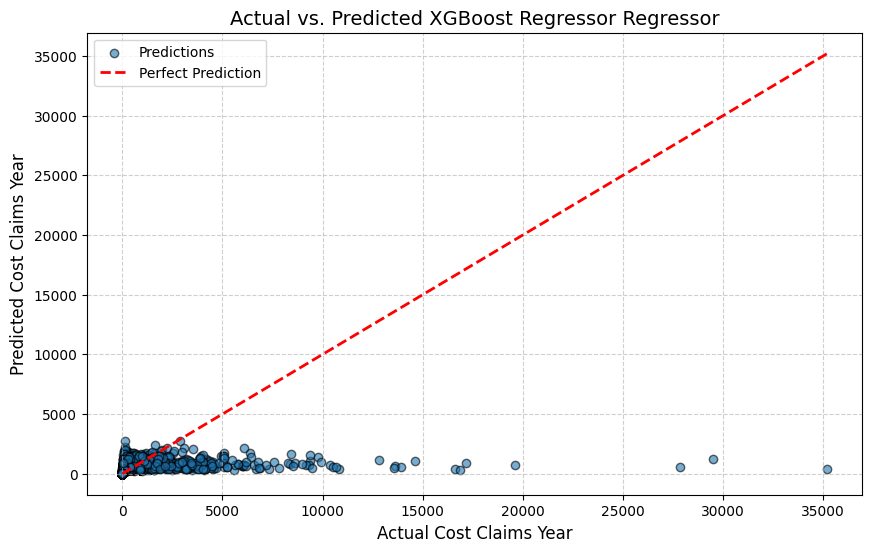

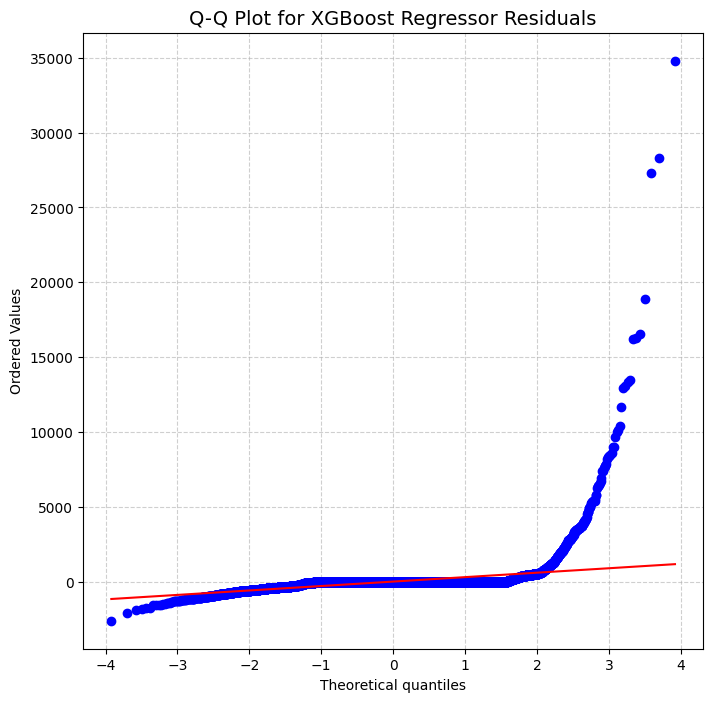

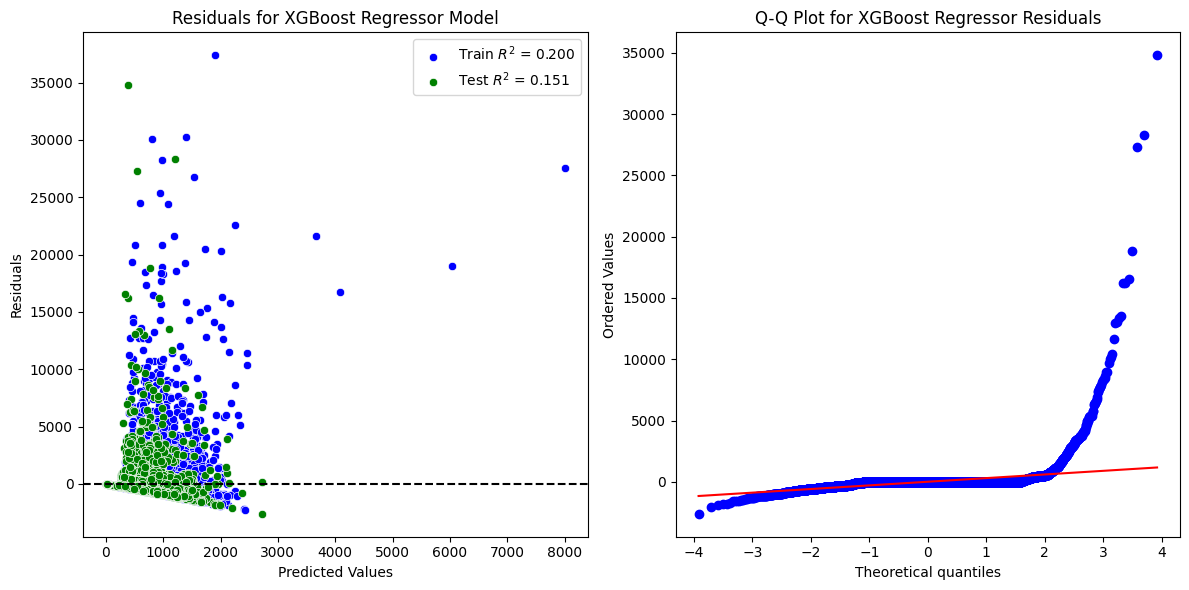

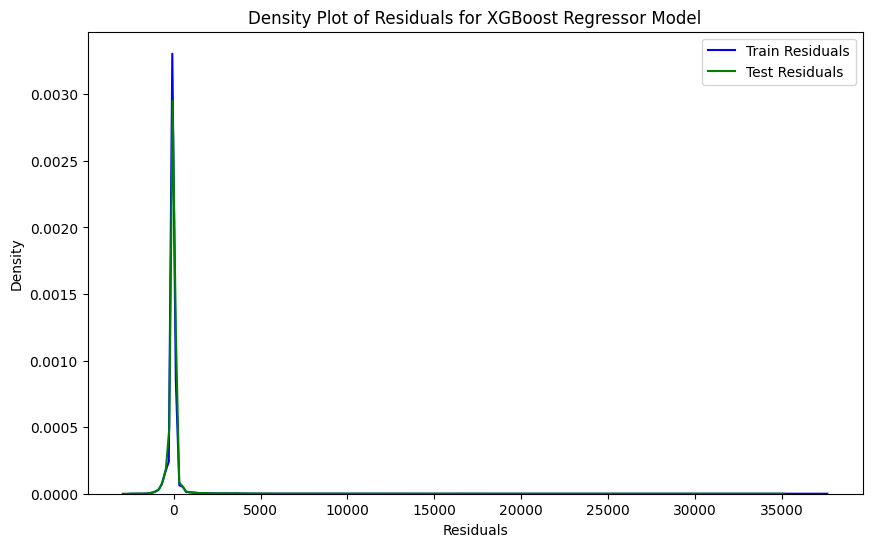

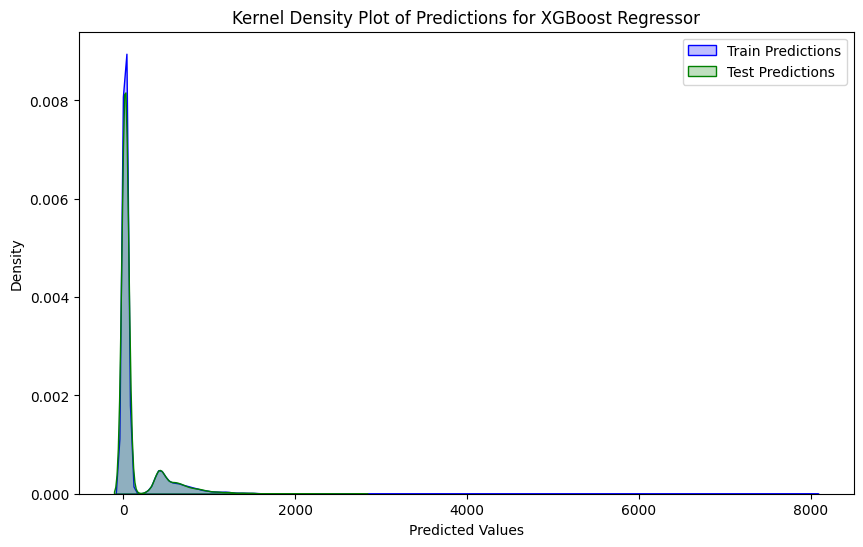

In [45]:

# Example: Selected features from Boruta or other feature selection methods
selected_features_xg = ["N_claims_year",
"Premium",
"Lapse",
"Driving_experience_years",
"Age_Group_25-39",
"R_Claims_history",
"Cylinder_capacity",
"Year_matriculation",
"Weight",
"Seniority"]
# Define the XGBoost regressor
model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# Define the parameter grid for hyperparameter tuning
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}
# Run the function
best_model = run_model_with_top_features_and_qq_plot(
    df_train=df_train,
    df_test=df_test,
    model=model,
    param_grid=param_grid,
    selected_features=selected_features_xg,  # Pass the selected features
    model_name="XGBoost Regressor"
)



MSE for each fold during CV:
  Fold 1: MSE = 661131.0198
  Fold 2: MSE = 496367.7358
  Fold 3: MSE = 534455.0504
  Fold 4: MSE = 621323.9901
  Fold 5: MSE = 466452.1975
Mean CV MSE: 555945.9987

Best Parameters from Grid Search for Random Forest:
{'subsample': 0.8, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.8}


Random Forest Model Evaluation on Full Training Set:
  Mean Squared Error (MSE): 551736.8283
  Mean Absolute Error (MAE): 138.4064
  R² Score: 0.1557

Random Forest Model Evaluation on Full Test Set:
  Mean Squared Error (MSE): 542469.3256
  Mean Absolute Error (MAE): 143.7147
  R² Score: 0.1517

Predictions have been saved to 'random_forest_Bu.csv'.


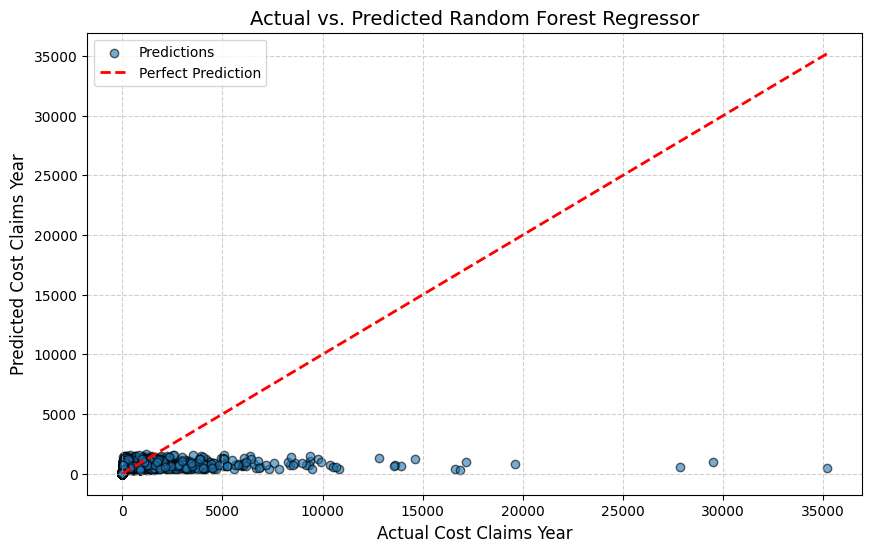

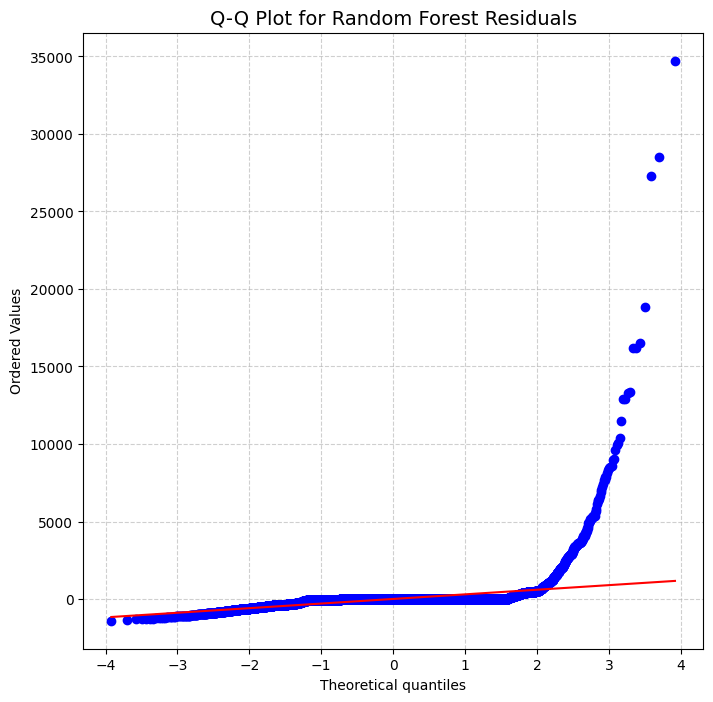

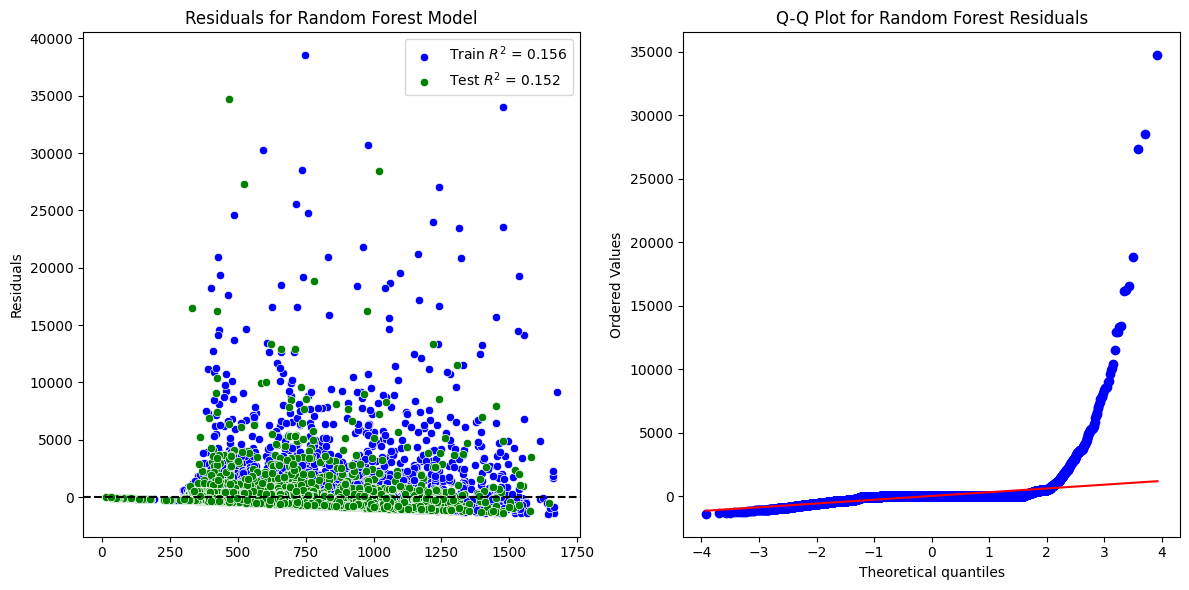

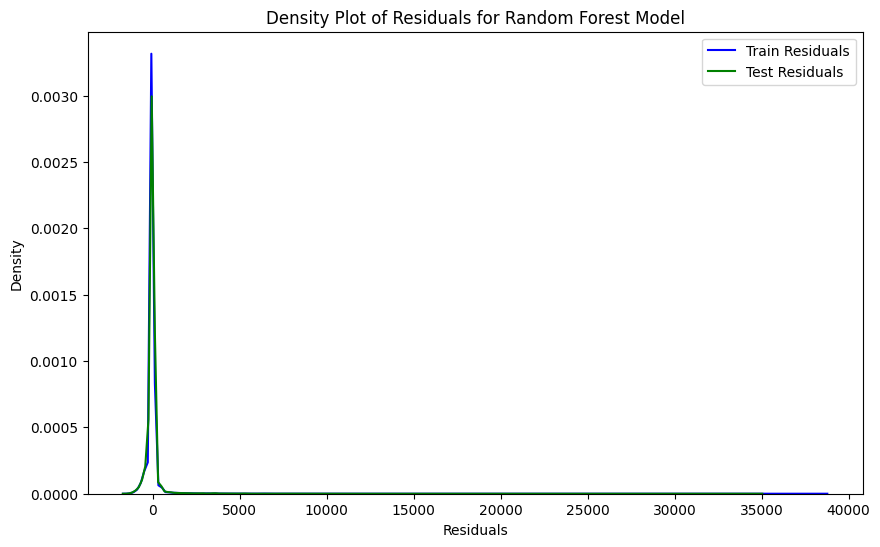

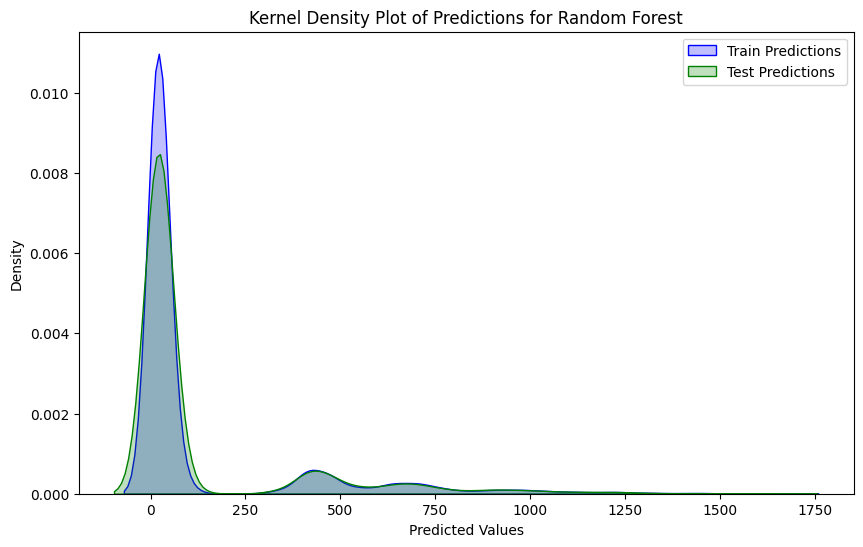

In [46]:
from sklearn.ensemble import RandomForestRegressor
# Example: Selected features from Boruta or other feature selection methods
selected_features_rf = [
"N_claims_year",
"Premium",
"R_Claims_history",
"Driving_experience_years",
"Year_matriculation",
"Value_vehicle",
"Weight",
"Power",
"Cylinder_capacity",
"N_claims_history"

]

rf_model = RandomForestRegressor(random_state=42)
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Run the function
best_model = run_model_with_top_features_and_qq_plot(
    df_train=df_train,
    df_test=df_test,
    model=model,
    param_grid=param_grid,
    selected_features=selected_features_rf,  
    model_name="Random Forest"
)
#8 mins 


MSE for each fold during CV:
  Fold 1: MSE = 661152.6472
  Fold 2: MSE = 496397.4572
  Fold 3: MSE = 534822.7158
  Fold 4: MSE = 621345.6657
  Fold 5: MSE = 466419.1506
Mean CV MSE: 556027.5273

Best Parameters from Grid Search for Gradient Boosting:
{'subsample': 0.8, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.8}


Gradient Boosting Model Evaluation on Full Training Set:
  Mean Squared Error (MSE): 551837.0136
  Mean Absolute Error (MAE): 138.4363
  R² Score: 0.1555

Gradient Boosting Model Evaluation on Full Test Set:
  Mean Squared Error (MSE): 542491.9209
  Mean Absolute Error (MAE): 143.7545
  R² Score: 0.1517

Predictions have been saved to 'gradient_boosting_Bu.csv'.


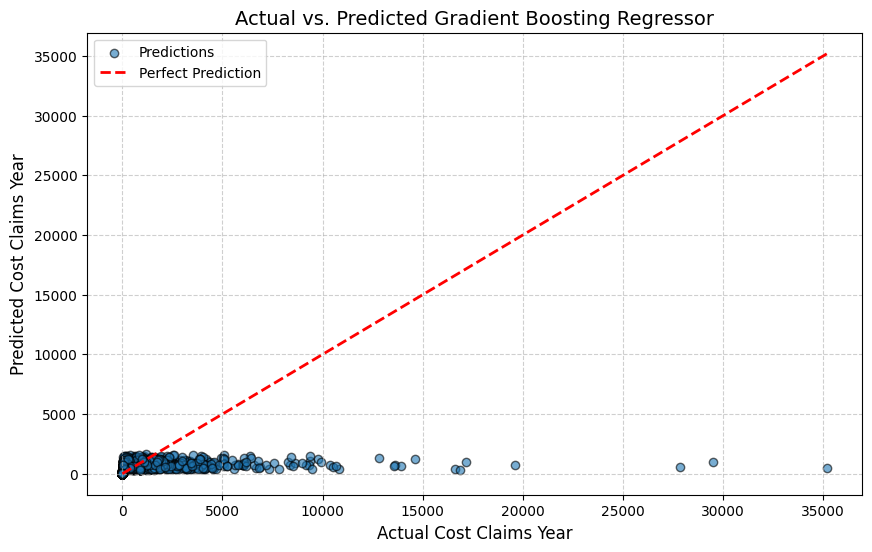

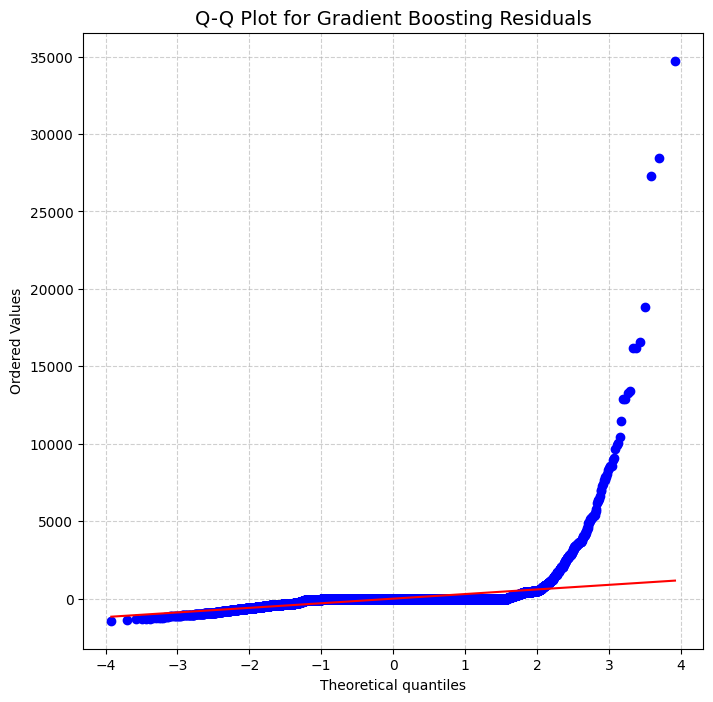

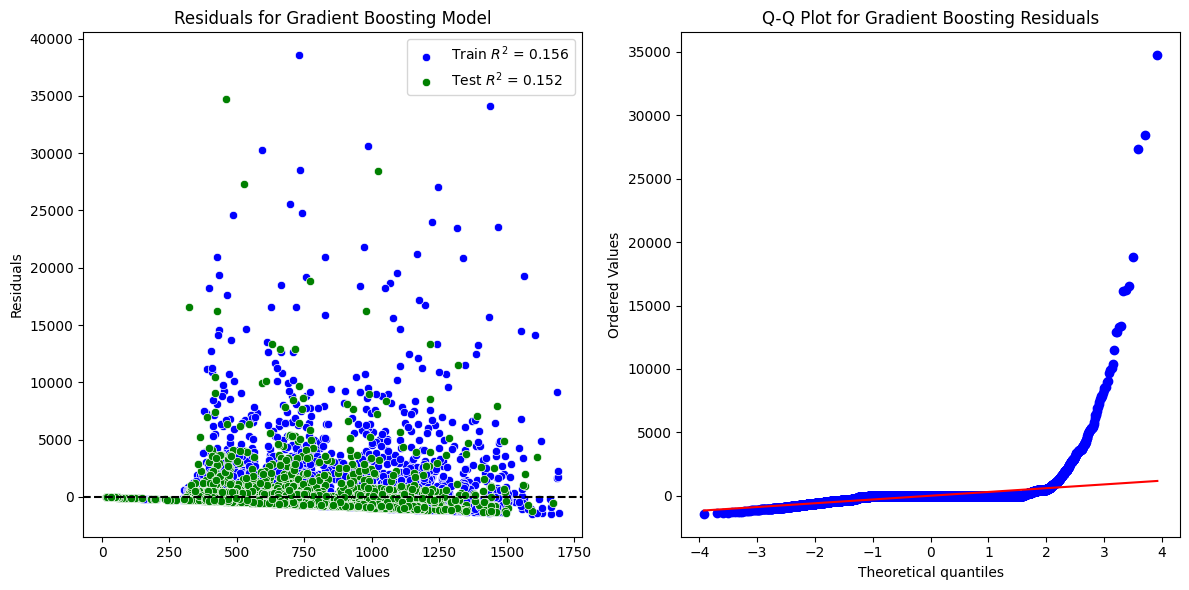

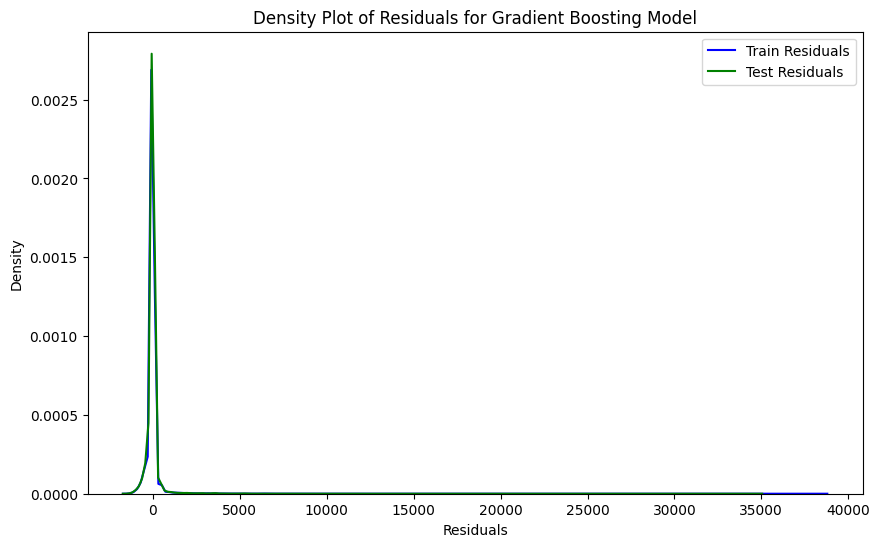

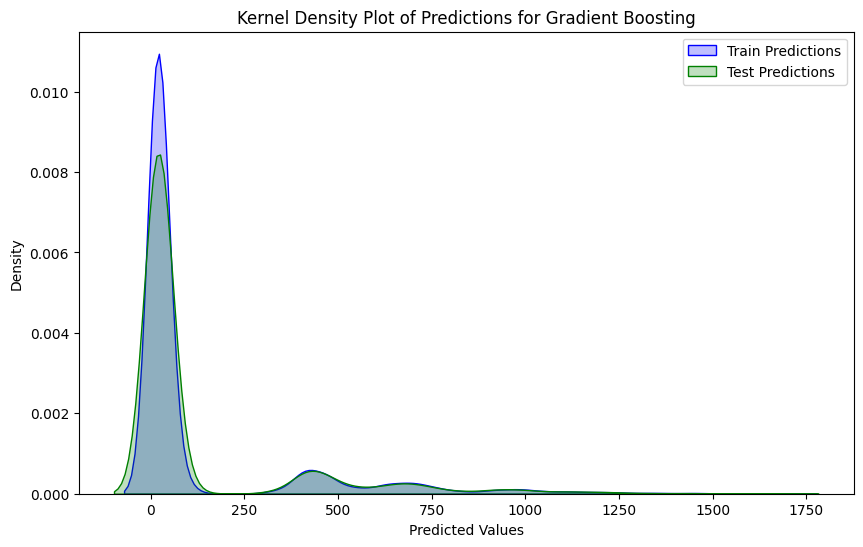

In [47]:
from sklearn.ensemble import GradientBoostingRegressor
selected_features_gb = [
"N_claims_year",
"R_Claims_history",
"Premium",
"Driving_experience_years",
"Weight",
"N_claims_history",
"Year_matriculation",
"Power",
"Value_vehicle",
"Cylinder_capacity"]

# Define Gradient Boosting Model and its hyperparameter grid
gbm_model = GradientBoostingRegressor(random_state=42)
gbm_param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Run the function
best_model = run_model_with_top_features_and_qq_plot(
    df_train=df_train,
    df_test=df_test,
    model=model,
    param_grid=param_grid,
    selected_features=selected_features_gb,  
    model_name="Gradient Boosting"
)


In [48]:
import pandas as pd

gb_Bu = pd.read_csv("gradient_boosting_Bu.csv")
gb_summary = gb_Bu[['y_true', 'y_pred']].describe()

print(f'\nGradient Boosting Bu Summary:\n{gb_summary}')

xg_Bu = pd.read_csv("xgboost_regressor_Bu.csv")
xg_summary = xg_Bu[['y_true', 'y_pred']].describe()
print(f'\nXGBoost Regressor Bu Summary:\n{xg_summary}')

rf_Bu = pd.read_csv("random_forest_Bu.csv")
rf_summary = rf_Bu[['y_true', 'y_pred']].describe()
print(f'\nRandom Forest Bu Summary:\n{rf_summary}')


Gradient Boosting Bu Summary:
             y_true        y_pred
count  15659.000000  15659.000000
mean     135.018277    129.803389
std      799.718784    256.567322
min        0.000000     14.092420
25%        0.000000     16.860476
50%        0.000000     17.277308
75%        0.000000     37.014429
max    35191.030000   1671.154800

XGBoost Regressor Bu Summary:
             y_true        y_pred
count  15659.000000  15659.000000
mean     135.018277    129.765996
std      799.718784    265.951502
min        0.000000     10.258280
25%        0.000000     17.534136
50%        0.000000     19.068348
75%        0.000000     33.831760
max    35191.030000   2730.758000

Random Forest Bu Summary:
             y_true        y_pred
count  15659.000000  15659.000000
mean     135.018277    129.736651
std      799.718784    256.120367
min        0.000000     14.833807
25%        0.000000     16.539001
50%        0.000000     18.109877
75%        0.000000     35.716230
max    35191.030000   1646.